Import librairies (caution : make sure that the "modules" folder is in the same folder as this script)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objs as go
import csv, os, joblib, time, shutil
import umap, pacmap
from tqdm import tqdm
from adjustText import adjust_text
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from tslearn.clustering import TimeSeriesKMeans
from sklearn.cluster import KMeans
import sklearn.decomposition, sklearn.metrics
import matplotlib.lines as mlines
from matplotlib.lines import Line2D
from scipy.spatial.distance import pdist, squareform
import pandas as pd
from collections import Counter
from modules import Functions, sammon, jqmcvi #home-made modules

/Users/qtaupin/Documents/these_aclr/IRAP/NASA Cosmic Dust Classification/Codes/nasa_classification_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/qtaupin/Documents/these_aclr/IRAP/NASA Cosmic Dust Classification/Codes/nasa_classification_env/lib/python3.12/site-packages/tslearn/bases/bases.py:16: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


Import data

In [2]:
######### IMPORTING DATA #########
print("\n# # # # # # # # # # # # # # # # # # # # # # # #")
catalog_numbers = ["1_1","1_2","2_1","2_2","3","4_1","4_2","5","6","7","8","9","10","11","12","13","14","15","17","18"]#["19","20","21","22","23","24","25"]
catalog_id = "1to18"#"1to6"
global_catalog_path = "../../Data/Data_csv/IDP_stats_csv/IDP_clean_with_years_full_period.csv"

importing_data_status = "to_create" # Or "to_load" if the data has already been created and saved in the "Clustering/Catalogues_Data" folder. If you want to create the data again, set it to "to_create".
print(f"Importing status : {importing_data_status}")

if importing_data_status == "to_create":
    memory_spectra = []
    memory_name_list = []
    memory_type_list = []
    memory_certainty_list = []
    memory_sizes_list = []
    memory_catalog_list = []
    memory_image_path_list = []
    memory_years_list = []
    memory_shapes_list = []
    memory_colors_list = []

    for i in tqdm(range(len(catalog_numbers)), desc="Loading catalogs : "):
        catalog_number = catalog_numbers[i]

        # Opening - EVERYTHING SHOULD HAVE BEEN NORMALIZED 
        if catalog_number=="18":
            input_path = f"../../Data/Data_csv/Catalog{catalog_number}/4_Time_warped_normalized_gaussian_filtered/"
            print(f" + Catalog {catalog_number} : spectra time warped, normalized and gaussian filtered")
        elif catalog_number=="1_1" or catalog_number=="1_2"or catalog_number=="2_1"or catalog_number=="2_2" or catalog_number=="3" or catalog_number=="8":
            input_path = f"../../Data/Data_csv/Catalog{catalog_number}/4_Converted_to_20_kV/"
            print(f" + Catalog {catalog_number} : spectra converted from 40 kV to 20 kV")
        elif catalog_number=="19" or catalog_number=="20"or catalog_number=="21"or catalog_number=="22" or catalog_number=="23" or catalog_number=="24" or catalog_number=="25":
            input_path = f"../../Data/Data_csv/Catalog{catalog_number}/4_Time_warped_normalized/"
        else:
            input_path = f"../../Data/Data_csv/Catalog{catalog_number}/3_Time_warped_normalized/"
        
        spectra_list_current, name_list_current, type_list_current, certainty_list_current, sizes_list, years_list, shapes_list, colors_list = Functions.opening(global_catalog_path, input_path)
    
        memory_spectra.append(spectra_list_current)
        memory_name_list.append(name_list_current)
        memory_type_list.append(type_list_current)
        memory_shapes_list.append(shapes_list)
        memory_colors_list.append(colors_list)
        memory_certainty_list.append(certainty_list_current)
        memory_sizes_list.append(sizes_list)
        memory_years_list.append(years_list)
        memory_catalog_list.append(np.array([catalog_number for i in range(len(spectra_list_current))], dtype=str))
        memory_image_path_list.append(np.array([f"../../Data/Data_all/Catalog{catalog_number}/Image/{particle_name}.png" for particle_name in name_list_current], dtype=str))

    spectra_list = np.concatenate((memory_spectra))
    joblib.dump(spectra_list, f"../../Data/Data_all/Clustering/Catalogues_Data/Catalog{catalog_id}/spectra_list.pkl")
    name_list = np.concatenate((memory_name_list), dtype=str)
    joblib.dump(name_list, f"../../Data/Data_all/Clustering/Catalogues_Data/Catalog{catalog_id}/name_list.pkl")
    type_list = np.concatenate((memory_type_list), dtype=str)
    joblib.dump(type_list, f"../../Data/Data_all/Clustering/Catalogues_Data/Catalog{catalog_id}/type_list.pkl")
    certainty_list = np.concatenate((memory_certainty_list), dtype=str)
    joblib.dump(certainty_list, f"../../Data/Data_all/Clustering/Catalogues_Data/Catalog{catalog_id}/certainty_list.pkl")
    sizes_list = np.concatenate((memory_sizes_list))
    joblib.dump(sizes_list, f"../../Data/Data_all/Clustering/Catalogues_Data/Catalog{catalog_id}/sizes_list.pkl")
    catalog_list = np.concatenate((memory_catalog_list), dtype=str)
    joblib.dump(catalog_list, f"../../Data/Data_all/Clustering/Catalogues_Data/Catalog{catalog_id}/catalog_list.pkl")
    years_list = np.concatenate((memory_years_list))
    joblib.dump(years_list, f"../../Data/Data_all/Clustering/Catalogues_Data/Catalog{catalog_id}/years_list.pkl")
    shapes_list = np.concatenate((memory_shapes_list), dtype=str)
    joblib.dump(shapes_list, f"../../Data/Data_all/Clustering/Catalogues_Data/Catalog{catalog_id}/shapes_list.pkl")
    colors_list = np.concatenate((memory_colors_list), dtype=str)
    joblib.dump(colors_list, f"../../Data/Data_all/Clustering/Catalogues_Data/Catalog{catalog_id}/colors_list.pkl")

elif importing_data_status == "to_load":
    spectra_list = joblib.load(f"../../Data/Data_all/Clustering/Catalogues_Data/Catalog{catalog_id}/spectra_list.pkl")
    name_list = joblib.load(f"../../Data/Data_all/Clustering/Catalogues_Data/Catalog{catalog_id}/name_list.pkl")
    type_list = joblib.load(f"../../Data/Data_all/Clustering/Catalogues_Data/Catalog{catalog_id}/type_list.pkl")
    certainty_list = joblib.load(f"../../Data/Data_all/Clustering/Catalogues_Data/Catalog{catalog_id}/certainty_list.pkl")
    sizes_list = joblib.load(f"../../Data/Data_all/Clustering/Catalogues_Data/Catalog{catalog_id}/sizes_list.pkl")
    catalog_list = joblib.load(f"../../Data/Data_all/Clustering/Catalogues_Data/Catalog{catalog_id}/catalog_list.pkl")
    years_list = joblib.load(f"../../Data/Data_all/Clustering/Catalogues_Data/Catalog{catalog_id}/years_list.pkl")
    shapes_list = joblib.load(f"../../Data/Data_all/Clustering/Catalogues_Data/Catalog{catalog_id}/shapes_list.pkl")
    colors_list = joblib.load(f"../../Data/Data_all/Clustering/Catalogues_Data/Catalog{catalog_id}/colors_list.pkl")



# # # # # # # # # # # # # # # # # # # # # # # #
Importing status : to_create


Loading catalogs :   0%|          | 0/20 [00:00<?, ?it/s]

Loading catalogs :   5%|▌         | 1/20 [00:00<00:02,  6.95it/s]

 + Catalog 1_1 : spectra converted from 40 kV to 20 kV
 + Catalog 1_2 : spectra converted from 40 kV to 20 kV


Loading catalogs :  15%|█▌        | 3/20 [00:00<00:02,  6.06it/s]

...

Loading catalogs :  55%|█████▌    | 11/20 [00:01<00:01,  5.92it/s]

 + Catalog 8 : spectra converted from 40 kV to 20 kV


Loading catalogs :  95%|█████████▌| 19/20 [00:05<00:00,  1.73it/s]

 + Catalog 18 : spectra time warped, normalized and gaussian filtered


Loading catalogs : 100%|██████████| 20/20 [00:07<00:00,  2.81it/s]


Reduce dimension

In [ ]:
######### DIMENSION REDUCTION ##########
reduction_type = "UMap"#Or "PaCMAP" "SMap" "UMap" "PCA" : in this paper we used UMap as it is fast and gives good visualization
dimensions = 2
reduction_status = "to_process" # Or "to_load" 
print("\n# # # # # # # # # # # # # # # # # # # # # # # #")
print(f"Reduction type : {reduction_type}")
print(f"Reduction status : {reduction_status}")


if reduction_type == "SMap":
    # Reduction with SMap
    saving_path_pkl_reduction = f"../../Data/Data_all/Clustering/Reduction_variables/Catalog{catalog_id}/SMap/{dimensions}D_backup.pkl"

if reduction_type == "UMap":
    # Reduction with UMap
    saving_path_pkl_reduction = f"../../Data/Data_all/Clustering/Reduction_variables/Catalog{catalog_id}/UMap/{dimensions}D_backup.pkl"

if reduction_type == "PaCMAP":
    # Reduction with PaCMAP
    saving_path_pkl_reduction = f"../../Data/Data_all/Clustering/Reduction_variables/Catalog{catalog_id}/PaCMAP/{dimensions}D_backup.pkl"

if reduction_type == "PCA":
    # Reduction with PCA
    saving_path_pkl_reduction = f"../../Data/Data_all/Clustering/Reduction_variables/Catalog{catalog_id}/PCA/{dimensions}D_backup.pkl"


if reduction_status == "to_process":
    # The reduction should be calculated
    if reduction_type == "SMap":
        # Sammon's map
        final_result = sammon.sammon(spectra_list, dimensions, magic=0.5)[0]
        joblib.dump(final_result, saving_path_pkl_reduction)

    if reduction_type == "UMap":
        # UMAP 
        umap_model = umap.UMAP(n_components=dimensions,  n_neighbors=75, min_dist=0.70, metric="euclidean", random_state=42)#0.70, n_neighbors=75
        final_result = umap_model.fit_transform(spectra_list)
        joblib.dump(final_result, saving_path_pkl_reduction)

    if reduction_type == "PaCMAP":
        # PaCMAP 
        pacmap_model = pacmap.PaCMAP(n_components=dimensions, n_neighbors=40, MN_ratio=4.0, FP_ratio=1.0)
        final_result = pacmap_model.fit_transform(spectra_list, init="pca")
        joblib.dump(final_result, saving_path_pkl_reduction)


elif reduction_status == "to_load" and reduction_type != "PCA":
    final_result = joblib.load(saving_path_pkl_reduction)

if reduction_type == "PCA":
    # PCA
    PCA_model = sklearn.decomposition.PCA(n_components=dimensions)
    final_result = PCA_model.fit_transform(spectra_list)

    # Principal components correlation coefficients
    loadings = PCA_model.components_


# # # # # # # # # # # # # # # # # # # # # # # #
Reduction type : UMap
Reduction status : to_process


/Users/qtaupin/Documents/these_aclr/IRAP/NASA Cosmic Dust Classification/Codes/nasa_classification_env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Clustering

In [ ]:
######### K-MEANS CLUSTERING #########
clustering_method = "KMeans"
nmb_clusters = 15 #24
metrics = "euclidean" # "euclidean" or "dtw" or "softdtw". Caution : other metrics than euclidean are very slow and not suitable for large datasets
centroids = False # "True" or "False" (creates a folder with the wanted number of closest spectra to each centroid cluster)
centroid_number_average = 5 # The number of spectra near to the centroid you want to get
clustering_status = "to_process" # Or "to_process" or "to_load" or "none" 
print("\n# # # # # # # # # # # # # # # # # # # # # # # #")
print(f"Clustering status : {clustering_status}")

## IF USING SELECTION clustering_status SHOULD BE to_load
with_selection = False # Or False
clusters_to_save = np.array([1,2,6,7,8,9,10,12,13])
selected_nmb_clusters = 11

# Split between references (pure elements and minerals) not to be clustered and spectra to be clustered
spectra_list_clustering = spectra_list[(type_list.flatten() != "M") & (type_list.flatten() != "ELMT")]
spectra_list_reference = spectra_list[(type_list.flatten() == "M") | (type_list.flatten() == "ELMT")]
name_list_clustering = name_list[(type_list.flatten() != "M") & (type_list.flatten() != "ELMT")]
name_list_reference = name_list[(type_list.flatten() == "M") | (type_list.flatten() == "ELMT")]
final_result_clustering = final_result[(type_list.flatten() != "M") & (type_list.flatten() != "ELMT")]
final_result_reference = final_result[(type_list.flatten() == "M") | (type_list.flatten() == "ELMT")]
type_list_reference = type_list[(type_list.flatten() == "M") | (type_list.flatten() == "ELMT")]
type_list_clustering = type_list[(type_list.flatten() != "M") & (type_list.flatten() != "ELMT")]
years_list_clustering = years_list[(type_list.flatten() != "M") & (type_list.flatten() != "ELMT")]
years_list_reference = years_list[(type_list.flatten() == "M") | (type_list.flatten() == "ELMT")]
shapes_list_clustering = shapes_list[(type_list.flatten() != "M") & (type_list.flatten() != "ELMT")]
shapes_list_reference = shapes_list[(type_list.flatten() == "M") | (type_list.flatten() == "ELMT")]
colors_list_clustering = colors_list[(type_list.flatten() != "M") & (type_list.flatten() != "ELMT")]
colors_list_reference = colors_list[(type_list.flatten() == "M") | (type_list.flatten() == "ELMT")]

if metrics == "euclidean":
    # Clustering of data with K-Means : euclidean 
    saving_path_pkl_clusters = f"../../Data/Data_all/Clustering/Clusters_variables/Catalog{catalog_id}/euclidean/TSKMeans_{str(nmb_clusters)}clusters_euclidean.pkl"

if metrics == "dtw":
    # Clustering of data with K-Means : dtw 
    saving_path_pkl_clusters = f"../../Data/Data_all/Clustering/Clusters_variables/Catalog{catalog_id}/dtw/TSKMeans_{str(nmb_clusters)}clusters_dtw.pkl"

if metrics == "softdtw":
    # Clustering of data with K-Means : softdtw 
    saving_path_pkl_clusters = f"../../Data/Data_all/Clustering/Clusters_variables/Catalog{catalog_id}/softdtw/TSKMeans_{str(nmb_clusters)}clusters_softdtw.pkl"


if clustering_status == "to_process":
    # If clustering needed to be calculated
    start_time = time.time()
    print("Number of clusters : " + str(nmb_clusters))
    print("Clustering metrics : " + metrics)

    #k_means = TimeSeriesKMeans(n_clusters=nmb_clusters, metric=metrics, random_state=42, n_init=10, max_iter=25) #this method allows to define the metric
    k_means = KMeans(n_clusters=nmb_clusters, random_state=42, n_init=10, max_iter=25, init='k-means++', verbose=1)
    clusters = k_means.fit_predict(spectra_list_clustering)
    joblib.dump(clusters, saving_path_pkl_clusters)

    elapsed_time = time.time() - start_time
    print("Total time with " + str(nmb_clusters) + " clusters : ", time.strftime("%H:%M:%S", time.gmtime(elapsed_time)))

    # Plotting the centroids if necessary
    if centroids == True:
        # Calculating the centroids and printing it
        centroids = Functions.centroids(spectra_list_clustering, name_list_clustering, clusters, nmb_clusters, centroid_number_average)
        print(centroids)

        ######### PLOTTING THE CENTROIDS #########
        title = f"{clustering_method}_{metrics}_{reduction_type}_{str(clustering_method)}_{str(nmb_clusters)}clust_Cat{catalog_id}"
        saving_path = f"../../Data/Data_all/Clustering/Graphiques/{reduction_type}/Catalog {catalog_id}/Clustering/{clustering_method}/{title}" 

        # Creating the directory if it doesn't exists
        for nmb in range(nmb_clusters):
            os.makedirs(f"{saving_path}/Cluster{str(nmb + 1)}", exist_ok=True)

        # Opening the global catalog
        with open(global_catalog_path, 'r') as csv_global:
            reader = csv.reader(csv_global)
            all_data = np.array([row for row in reader], dtype=str)[1:]

            particle_names = all_data[:,0]
            catalog_numbers = all_data[:,1]

        particle_names = np.array(particle_names, dtype=str)
        catalog_numbers = np.array(catalog_numbers, dtype=str)

        cluster_index = 0

        for names in centroids['Closest spectra name'].values:
            for i in range(centroid_number_average):
                name = names[i]
                catalog_number = str(catalog_numbers[np.where(name == particle_names)][0])
                source_path = f"../../Data/Data_all/Catalog{catalog_number}/Catalog{catalog_number}_pdf_checked/{name}.pdf"
                destination_path = f"{saving_path}/Cluster{cluster_index + 1}/Spectra_image_average_{i + 1}.pdf"
                #source_path_2 = f"../../Data/Data_all/Catalog{catalog_number}/Preprocessing/V8/5_Spectra_images/{str(name[:5])+'_'+str(name[5:])}.pdf"
                #destination_path_2 = f"{saving_path}/Cluster{cluster_index + 1}/Spectra_average_{i + 1}.pdf"
                #shutil.copy(source_path_2, destination_path_2)
                shutil.copy(source_path, destination_path)

            cluster_index += 1
            

elif clustering_status == "to_load":
    if with_selection == False:
        # If just needed to be load
        clusters = joblib.load(saving_path_pkl_clusters)
        title = f"TS_{metrics}_{reduction_type}_{str(nmb_clusters)}clust_Cat{catalog_id}"
        print(f"Number of clusters : {str(nmb_clusters)}")
        print(f"Clustering metrics : {metrics}")

    elif with_selection == True:
        saving_path_pkl_clusters_selected = f"../../Data/Data_all/Clustering/Clusters_variables/Catalog{catalog_id}/euclidean/TSKMeans_{str(nmb_clusters)}clusters_euclidean_{str(clusters_to_save)}_{selected_nmb_clusters}.pkl"
        clusters = joblib.load(saving_path_pkl_clusters_selected)
        title = f"TS_{metrics}_{reduction_type}_{str(nmb_clusters)}clust_Cat{catalog_id}_{str(clusters_to_save)}_{selected_nmb_clusters}"
        print(f"Number of initial clusters : {str(nmb_clusters)}")
        print(f"Selected clusters : {clusters_to_save}")
        print(f"Number of clusters in the selection : {selected_nmb_clusters}")
        print(f"Clustering metrics : {metrics}")
        
        # Updating nmb_clusters for centroids function
        nmb_clusters = nmb_clusters + selected_nmb_clusters - len(clusters_to_save)

    # Plotting the centroids if necessary
    if centroids == True:
        # Calculating the centroids and printing it
        centroids = Functions.centroids(spectra_list_clustering, name_list_clustering, clusters, nmb_clusters, centroid_number_average)
        print(centroids)

        ######### PLOTTING THE CENTROIDS #########
        saving_path = f"../../Data/Data_all/Clustering/Graphiques/{reduction_type}/Catalog {catalog_id}/Clustering/{title}" 

        # Creating the directory if it doesn't exists
        for nmb in range(nmb_clusters):
            os.makedirs(f"{saving_path}/Cluster{str(nmb + 1)}", exist_ok=True)

        # Opening the global catalog
        with open(global_catalog_path, 'r') as csv_global:
            reader = csv.reader(csv_global)
            all_data = np.array([row for row in reader], dtype=str)[1:]

            particle_names = all_data[:,0]
            catalog_numbers = all_data[:,1]

        particle_names = np.array(particle_names, dtype=str)
        catalog_numbers = np.array(catalog_numbers, dtype=str)

        cluster_index = 0

        for names in centroids['Closest spectra name'].values:
            for i in range(centroid_number_average):
                name = names[i]
                catalog_number = str(catalog_numbers[np.where(name == particle_names)][0])
                source_path = f"../../Data/Data_all/Catalog{catalog_number}/Catalog{catalog_number}_pdf_checked/{name}.pdf"
                destination_path = f"{saving_path}/Cluster{cluster_index + 1}/Spectra_image_average_{i + 1}.pdf"
                #source_path_2 = f"../../Data/Data_all/Catalog{catalog_number}/Preprocessing/V8/5_Spectra_images/{str(name[:5])+'_'+str(name[5:])}.pdf"
                #destination_path_2 = f"{saving_path}/Cluster{cluster_index + 1}/Spectra_average_{i + 1}.pdf"
                #shutil.copy(source_path_2, destination_path_2)
                shutil.copy(source_path, destination_path)

            cluster_index += 1



# # # # # # # # # # # # # # # # # # # # # # # #
Clustering status : to_process
Number of clusters : 15
Clustering metrics : euclidean
Initialization complete
Iteration 0, inertia 7.377281092610164.
Iteration 1, inertia 5.614028132592846.
Iteration 2, inertia 5.490190082461434.
Iteration 3, inertia 5.398128091367718.
Iteration 4, inertia 5.275274675068496.
Iteration 5, inertia 5.215115061771061.
Iteration 6, inertia 5.20030969882384.
Iteration 7, inertia 5.187014400955033.
Iteration 8, inertia 5.176986630381222.
Iteration 9, inertia 5.172560367062893.
Iteration 10, inertia 5.169317059786817.
Iteration 11, inertia 5.152187695753105.
Iteration 12, inertia 5.1112333791618525.
Iteration 13, inertia 5.060672686021315.
Iteration 14, inertia 5.057875991581055.
Iteration 15, inertia 5.057373312784582.
Iteration 16, inertia 5.057255400339777.
Iteration 17, inertia 5.057192850623906.
Iteration 18, inertia 5.0571879654453475.
Iteration 19, inertia 5.05717678422147.
Iteration 20, inertia 5.0571485


# # # # # # # # # # # # # # # # # # # # # # # #
Plotting mode : NASA_Gradient
Years displayed : [1981, 1982, 1983, 1984, 1985, 1987, 1988, 1989, 1991, 1994, 1996, 1999, 2000, 2008, 2009, 2010]


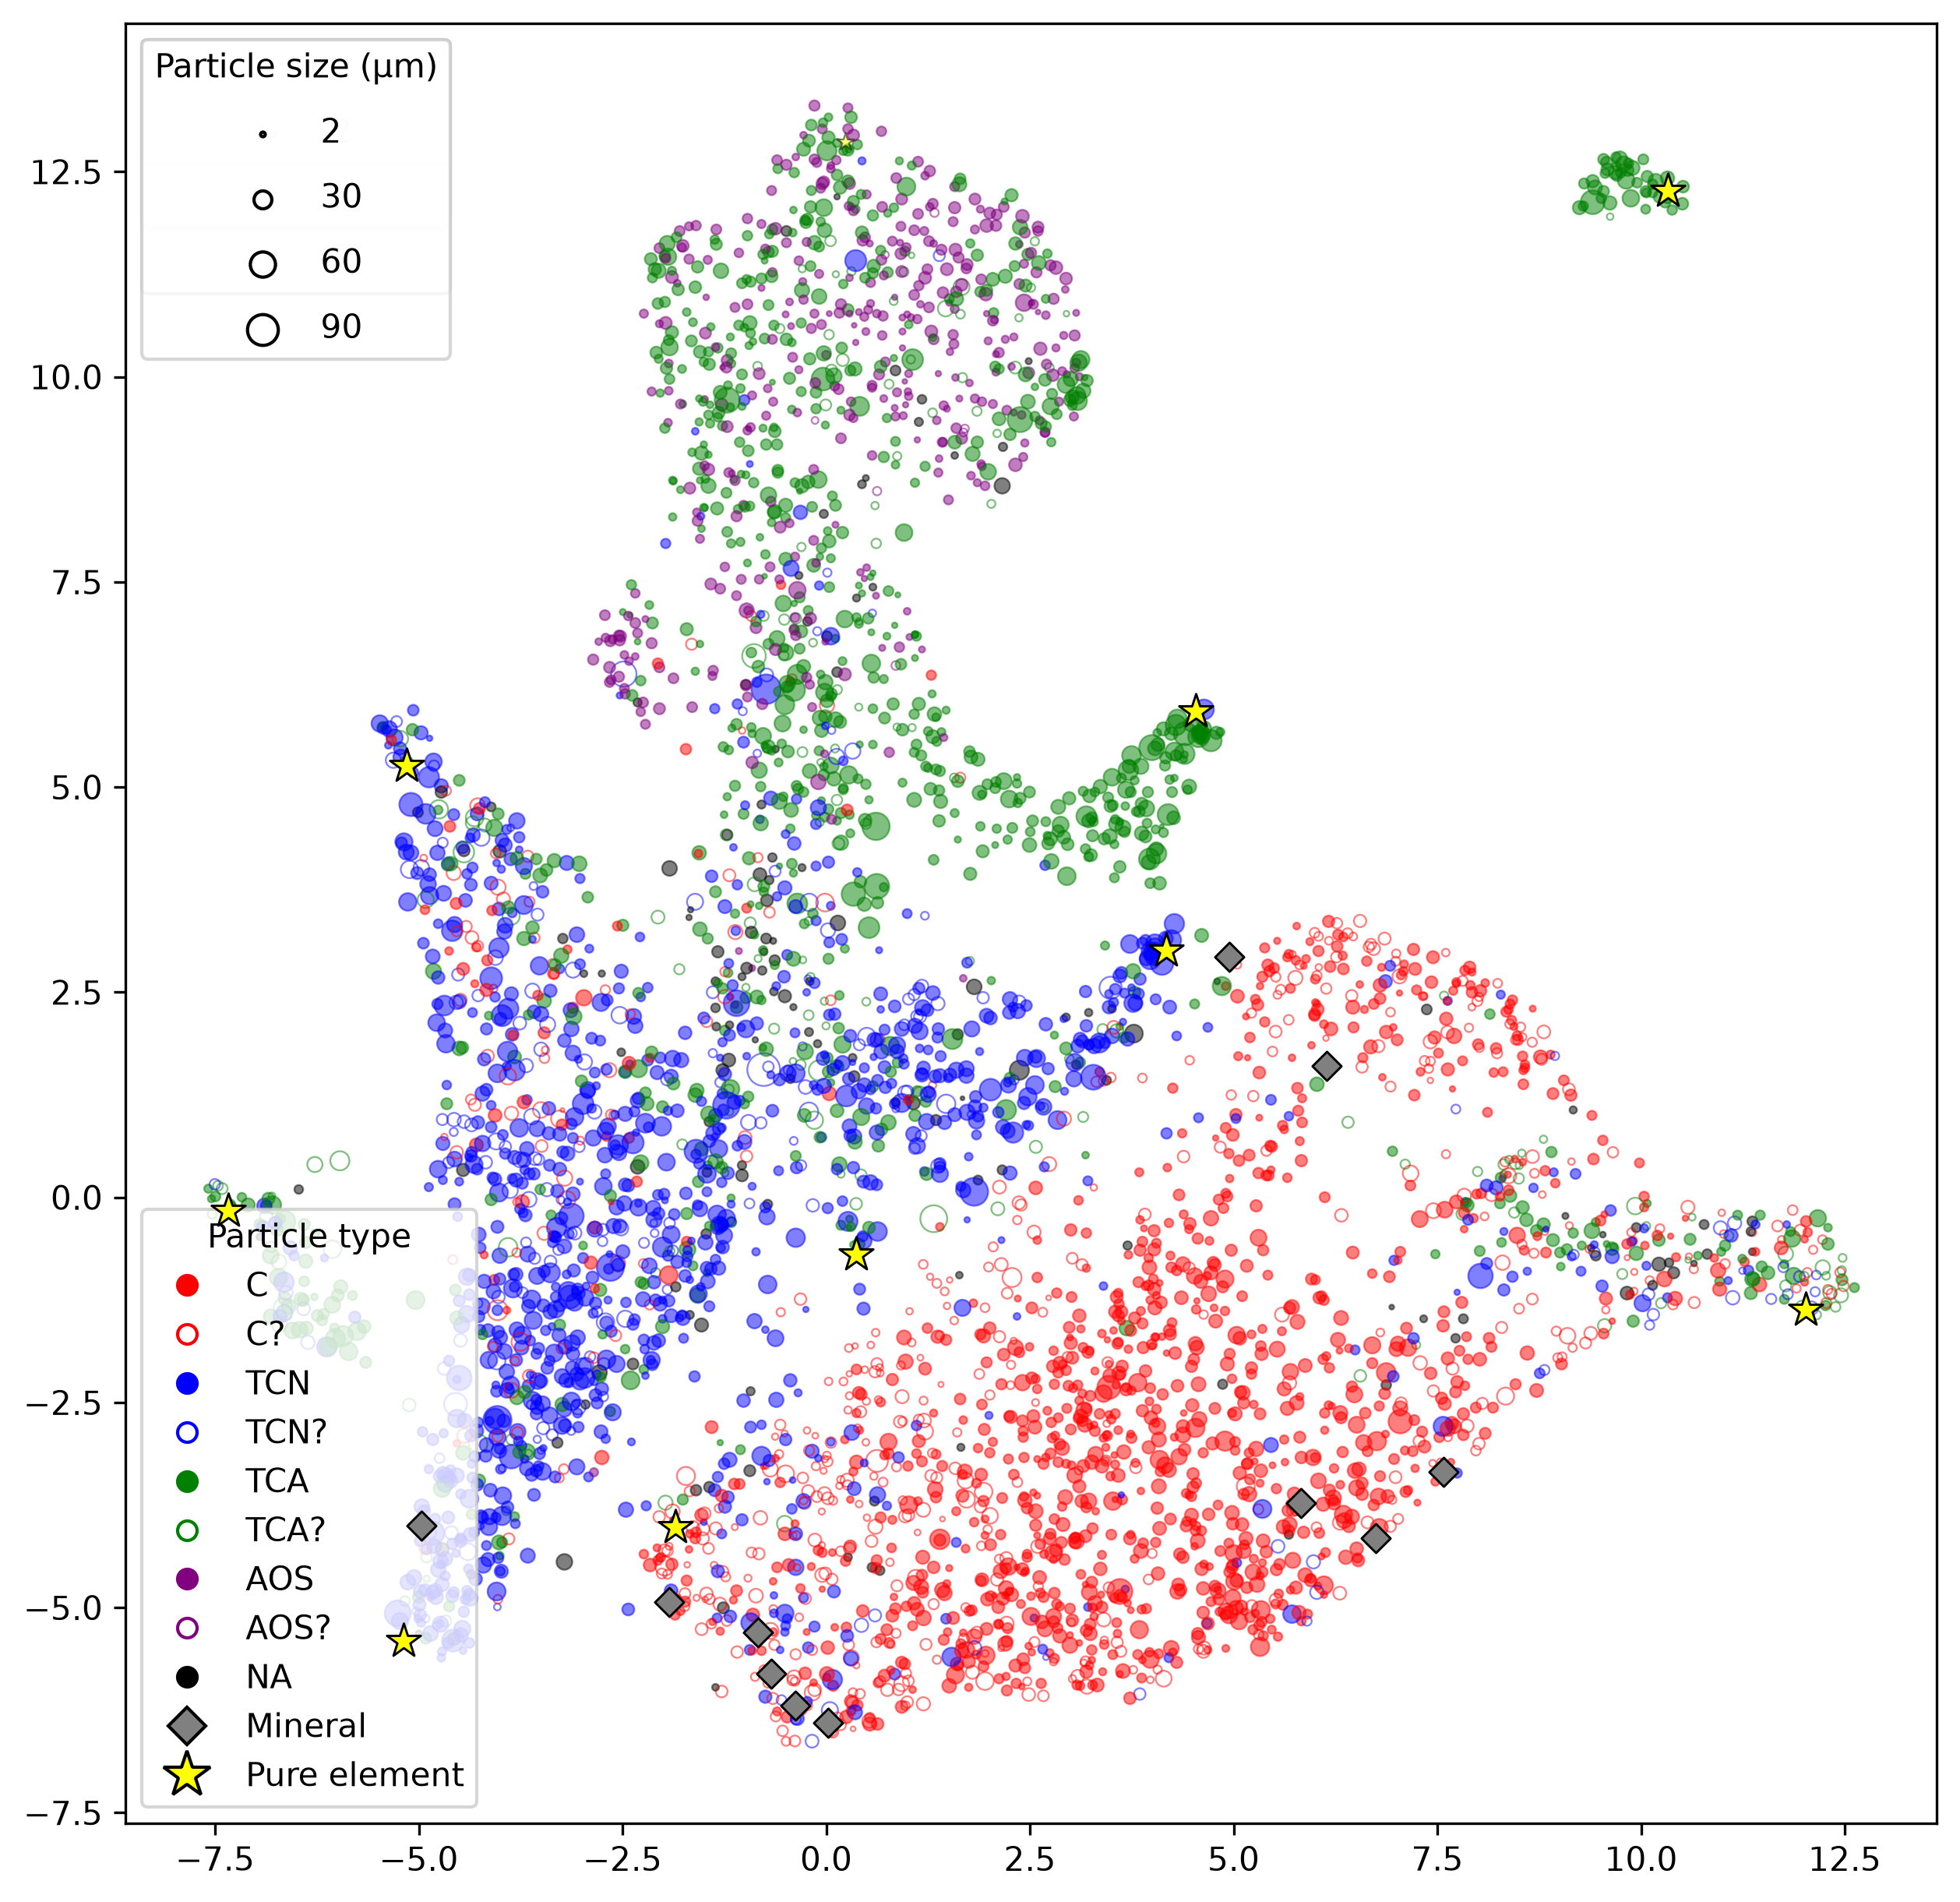

In [ ]:
######### PLOT CLASSIFICATION MAP #########

# ---- USER INPUT ----
years_to_display = [1981, 1982, 1983, 1984, 1985, 1987, 1988, 1989, 1991, 1994, 1996, 1999, 2000, 2008, 2009, 2010]#[, 2012, 2014, 2015, 2016, 2017, 2018, 2020]#[2012, 2014, 2015, 2016, 2017, 2018, 2020]#[1981, 1982, 1983, 1984, 1985, 1987, 1988, 1989, 1991, 1994, 1996, 1999, 2000, 2008, 2009, 2010]#[2010]#, 1982, 1983, 1984, 1985, 1987, 1988, 1989, 1991, 1994, 1996, 1999, 2000, 2008, 2009, 2010]#[1981]#  # [] -> display nothing

plotting_mode = "NASA_Gradient"  # "Clustering" or "NASA" or "NASA_Gradient"
showing = True
using_plotly = False  # "False" or "True" only with NASA plotting mode (to plot the map in a special window to access dynamically to the names of every wanted particle)
name_clusters=['S-rich','Al-rich','Mg and Ca-rich','Fe and S-rich','Si-rich','Cr-rich','Mg and Fe-rich','Al-rich and other metals','Fe-rich','Ti-rich','Cd-rich','Cu-rich','Mg-rich','Ca and Si-rich','Ca-rich']
#name_clusters=['1','2','3','4','5','6','7','8','9','10','11', '12', '13']#['1','2','3','4','5','6','7','8','9','10','11','12','13','14']
print("\n# # # # # # # # # # # # # # # # # # # # # # # #")
print(f"Plotting mode : {plotting_mode}")
print(f"Years displayed : {years_to_display}")

# ---- BUILD MASK FROM YEARS ----
years_array = np.asarray(years_list).astype(int).ravel()

if len(years_to_display) == 0:
    mask = np.zeros(len(years_array), dtype=bool)
else:
    mask = np.isin(years_array, np.asarray(years_to_display, dtype=int))

# ---- COLOR / MARKER ASSIGNMENT ----
if plotting_mode == "NASA":
    particle_color, particle_marker, legend_elements = Functions.NASA_color(
        type_list, certainty_list, dimensions, using_plotly
    )
    #title = f"NASA_{reduction_type}_Cat{catalog_id}\nYears {', '.join(map(str, years_to_display))}"

elif plotting_mode == "Clustering":
    particle_color, particle_marker, legend_elements = Functions.clustering_color(
        clusters, nmb_clusters,name_clusters
    )
    #title = f"Clustering_{reduction_type}_Cat{catalog_id}\nYears {', '.join(map(str, years_to_display))}"

elif plotting_mode == "NASA_Gradient":
    type_list_uncertain = type_list.copy()
    # Replace values where the second array is "N"
    #type_list_uncertain[certainty_list == "N"] = "?"
    type_list_uncertain[(certainty_list == "N") &np.isin(type_list_uncertain, ["AOS", "TCA", "TCN", "C"])] += "?"

    particle_color, particle_marker, legend_elements, legend_elements_bis, sizes, particle_edgecolor = (
        Functions.color_gradient_NASA(type_list_uncertain, sizes_list)
    )
    #title = f"NASA_Gradient_{reduction_type}_Cat{catalog_id}\nYears {', '.join(map(str, years_to_display))}"

    fixed_sizes = [2, 30, 60, 90]
    legend_elements_bis = [(size, f"{size}") for size in fixed_sizes]

else:
    raise ValueError(f"Unknown plotting mode: {plotting_mode}")

saving_path = (
    f"../../Data/Data_all/Clustering/Graphiques/{reduction_type}/"
    f"Catalog {catalog_id}/{plotting_mode}/s20_edge_small.pdf"
)

#offset = np.array([-0.03, -0.03])

# ========= VISUALIZATION =========

if using_plotly is False:
    fig, ax = plt.subplots(figsize=(10, 10), dpi=300)
    texts = []

    # ---- REFERENCE POINTS ----
    for j in range(len(final_result_reference[:, 1])):

        if type_list_reference[j] == 'M':
            ax.scatter(
                final_result_reference[j, 1],
                final_result_reference[j, 0],
                color='grey',
                marker='D',
                s=40,
                alpha=1,
                edgecolor='black',
                linewidth=0.7,
                zorder=20
            )

        elif type_list_reference[j] == 'ELMT' and name_list_reference[j] != 'syntheticAl':
            ax.scatter(
                final_result_reference[j, 1],
                final_result_reference[j, 0],
                color='yellow',
                marker='*',
                s=120,
                alpha=1,
                edgecolor='black',
                linewidth=0.7,
                zorder=20
            )


    if plotting_mode != "NASA_Gradient":

        for j in range(len(final_result_clustering[:, 1])):

            if mask[j]:
                ax.scatter(
                    final_result_clustering[j, 1],
                    final_result_clustering[j, 0],
                    color=particle_color[j],
                    marker=particle_marker[j],
                    s=30,
                    alpha=0.4,
                    edgecolor='black',
                    linewidth=0.5
                )

    else:
        # ---- NASA GRADIENT MODE ----
        for j in range(len(final_result[:, 1])):

            if mask[j]:
                ax.scatter(
                    final_result[j, 1],
                    final_result[j, 0],
                    s=sizes[j],
                    color=particle_color[j],
                    marker=particle_marker[j],
                    alpha=0.5,
                    edgecolor=particle_edgecolor[j],
                    linewidth=0.55
                )

        for size, label in legend_elements_bis:
            ax.scatter([], [], s=size, label=label, edgecolor='black', facecolor='white')

            first_legend = ax.legend(
                scatterpoints=1,
                frameon=True,
                labelspacing=1,
                title="Particle size (µm)",
                #bbox_to_anchor=(1.05, 1),  # Déplace la légende à l'extérieur à droite
                loc='upper left'
                #borderaxespad=0.
            )
            ax.add_artist(first_legend)

            ax.legend(
                handles=legend_elements,
                fontsize='medium',
                title="Particle type",
                #bbox_to_anchor=(1.05, 0.7),  # Déplace la légende en dessous de la première
                loc='lower left'
                #borderaxespad=0.
            )

    x_min, x_max=ax.get_xlim()
    y_min, y_max=ax.get_ylim()

    if reduction_type != "PCA" and plotting_mode != "NASA_Gradient":
        legend_elements += [
            mlines.Line2D([0], [0], marker='D', linestyle='None', markerfacecolor='black', markeredgecolor='black',
                          markersize=10, label="Mineral"),
            mlines.Line2D([0], [0], marker='*', linestyle='None', markerfacecolor='yellow', markeredgecolor='black',
                          markersize=12, label="Pure element")
        ]
        ax.legend(
            handles=legend_elements,
            fontsize='large',
            bbox_to_anchor=(1.35, 1),
            loc='upper right',
            borderaxespad=0.
        )


    if showing:
        plt.show()

    plt.close(fig)

elif using_plotly == True:
    fig = go.Figure()

    for j in range(len(final_result)):
        fig.add_trace(
            go.Scatter(x=[final_result[j][1]], y=[final_result[j][0]], mode='markers', marker=dict(color=particle_color[j],
                                                                                                    symbol=particle_marker[j],
                                                                                                    size=5,
                                                                                                    opacity=0.4,
                                                                                                    line=dict(color='black', width=0)
                                                                                                ), 
                        text=f"Name : {name_list[j]} Catalog : {catalog_list[j]}", hoverinfo='text')
        )
    fig.update_layout(
        #title=title,
        width=800,  
        height=800,
        showlegend=False
    )
    #fig.update_layout(
        #xaxis_title='First principle component',
        #yaxis_title='Second principle component',
       # title=title,
        #width=800,  
        #height=800,
        #showlegend=False
    #)
    fig.show()


# # # # # # # # # # # # # # # # # # # # # # # #
Plotting mode : NASA_Gradient
Years displayed : [1981, 1982, 1983, 1984, 1985, 1988, 1989, 1991, 1994, 1996, 1999, 2000, 2008, 2009, 2010]


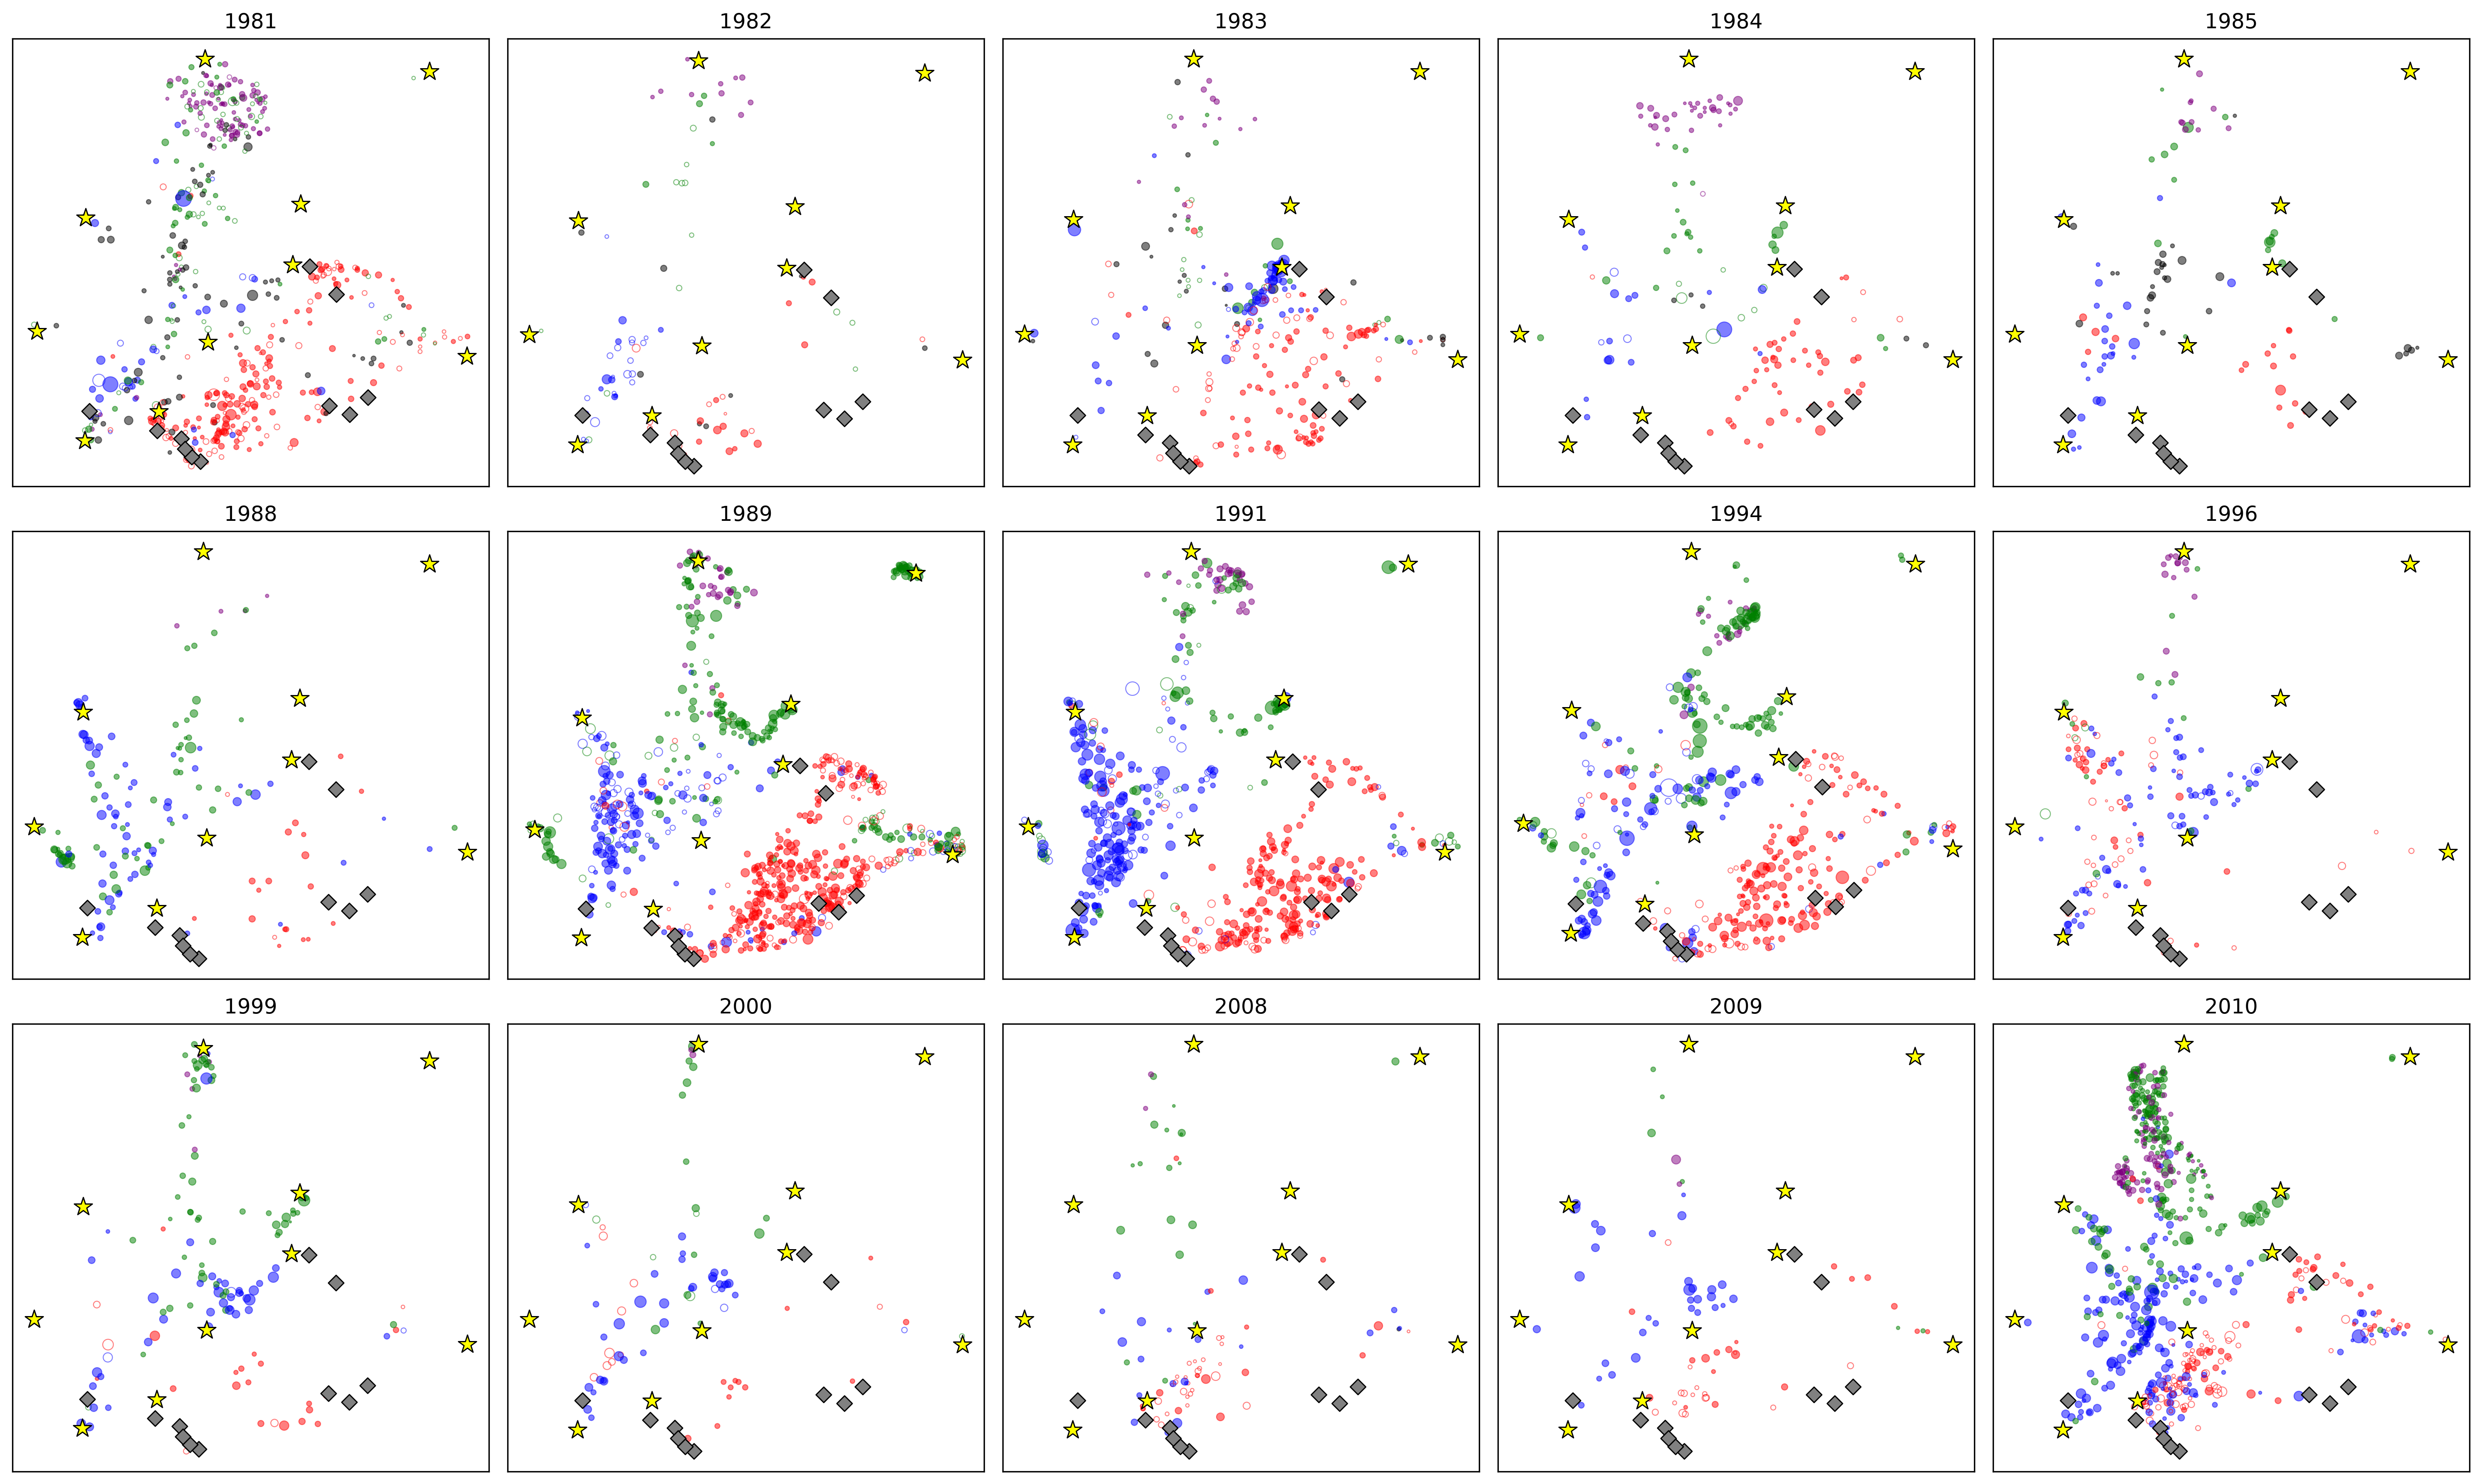

In [7]:
######### PLOTTING RESULT (NASA GRADIENT GRID BY YEAR) #########

import numpy as np
import matplotlib.pyplot as plt
import math

# ---- USER INPUT ----
years_to_display = [1981, 1982, 1983, 1984, 1985, 1988, 1989,
                    1991, 1994, 1996, 1999, 2000, 2008, 2009, 2010]

plotting_mode = "NASA_Gradient"
showing = True

print("\n# # # # # # # # # # # # # # # # # # # # # # # #")
print(f"Plotting mode : {plotting_mode}")
print(f"Years displayed : {years_to_display}")

# ---- YEAR ARRAY ----
years_array = np.asarray(years_list).astype(int).ravel()

# ---- NASA GRADIENT COLORS ----
type_list_uncertain = type_list.copy()

type_list_uncertain[
    (certainty_list == "N") &
    np.isin(type_list_uncertain, ["AOS", "TCA", "TCN", "C"])
] += "?"

particle_color, particle_marker, legend_elements, legend_elements_bis, sizes, particle_edgecolor = (
    Functions.color_gradient_NASA(type_list_uncertain, sizes_list)
)

# Fixed size legend
fixed_sizes = [2, 30, 60, 90]
legend_elements_bis = [(size, f"{size}") for size in fixed_sizes]

# ---- SAFE LENGTH ----
n_particles = min(
    len(final_result),
    len(particle_color),
    len(particle_marker),
    len(particle_edgecolor),
    len(sizes),
    len(years_array)
)

# ---- GRID SETUP ----
years_to_display = np.asarray(years_to_display)

n_years = len(years_to_display)
ncols = 5
nrows = math.ceil(n_years / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows), dpi=300)
axes = axes.flatten()

# ========= PLOTTING =========

for i, year in enumerate(years_to_display):

    ax = axes[i]

    year_mask = (years_array[:n_particles] == year)
    indices = np.where(year_mask)[0]

    # ---- REFERENCE POINTS ----
    for j in range(len(final_result_reference[:, 1])):

        if type_list_reference[j] == 'M':
            ax.scatter(
                final_result_reference[j,1],
                final_result_reference[j,0],
                color='grey',
                marker='D',
                s=40,
                edgecolor='black',
                linewidth=0.7,
                zorder=20
            )

        elif type_list_reference[j] == 'ELMT':
            ax.scatter(
                final_result_reference[j,1],
                final_result_reference[j,0],
                color='yellow',
                marker='*',
                s=120,
                edgecolor='black',
                linewidth=0.7,
                zorder=20
            )

    # ---- PARTICLES ----
    for j in indices:
        ax.scatter(
            final_result[j,1],
            final_result[j,0],
            s=sizes[j],
            color=particle_color[j],
            marker=particle_marker[j],
            alpha=0.5,
            edgecolor=particle_edgecolor[j],
            linewidth=0.55
        )

    ax.set_title(str(year))
    ax.set_xticks([])
    ax.set_yticks([])

# ---- HIDE UNUSED SUBPLOTS ----
for j in range(n_years, len(axes)):
    axes[j].axis("off")

# ========= LEGENDS (ONLY ONCE) =========

# Size legend
for size, label in legend_elements_bis:
    axes[0].scatter([], [], s=size, label=label,
                    edgecolor='black', facecolor='white')



plt.tight_layout()

if showing:
    plt.show()

plt.close(fig)


# # # # # # # # # # # # # # # # # # # # # # # #
Plotting mode : Clustering
Years displayed : [1981, 1982, 1983, 1984, 1985, 1988, 1989, 1991, 1994, 1996, 1999, 2000, 2008, 2009, 2010]


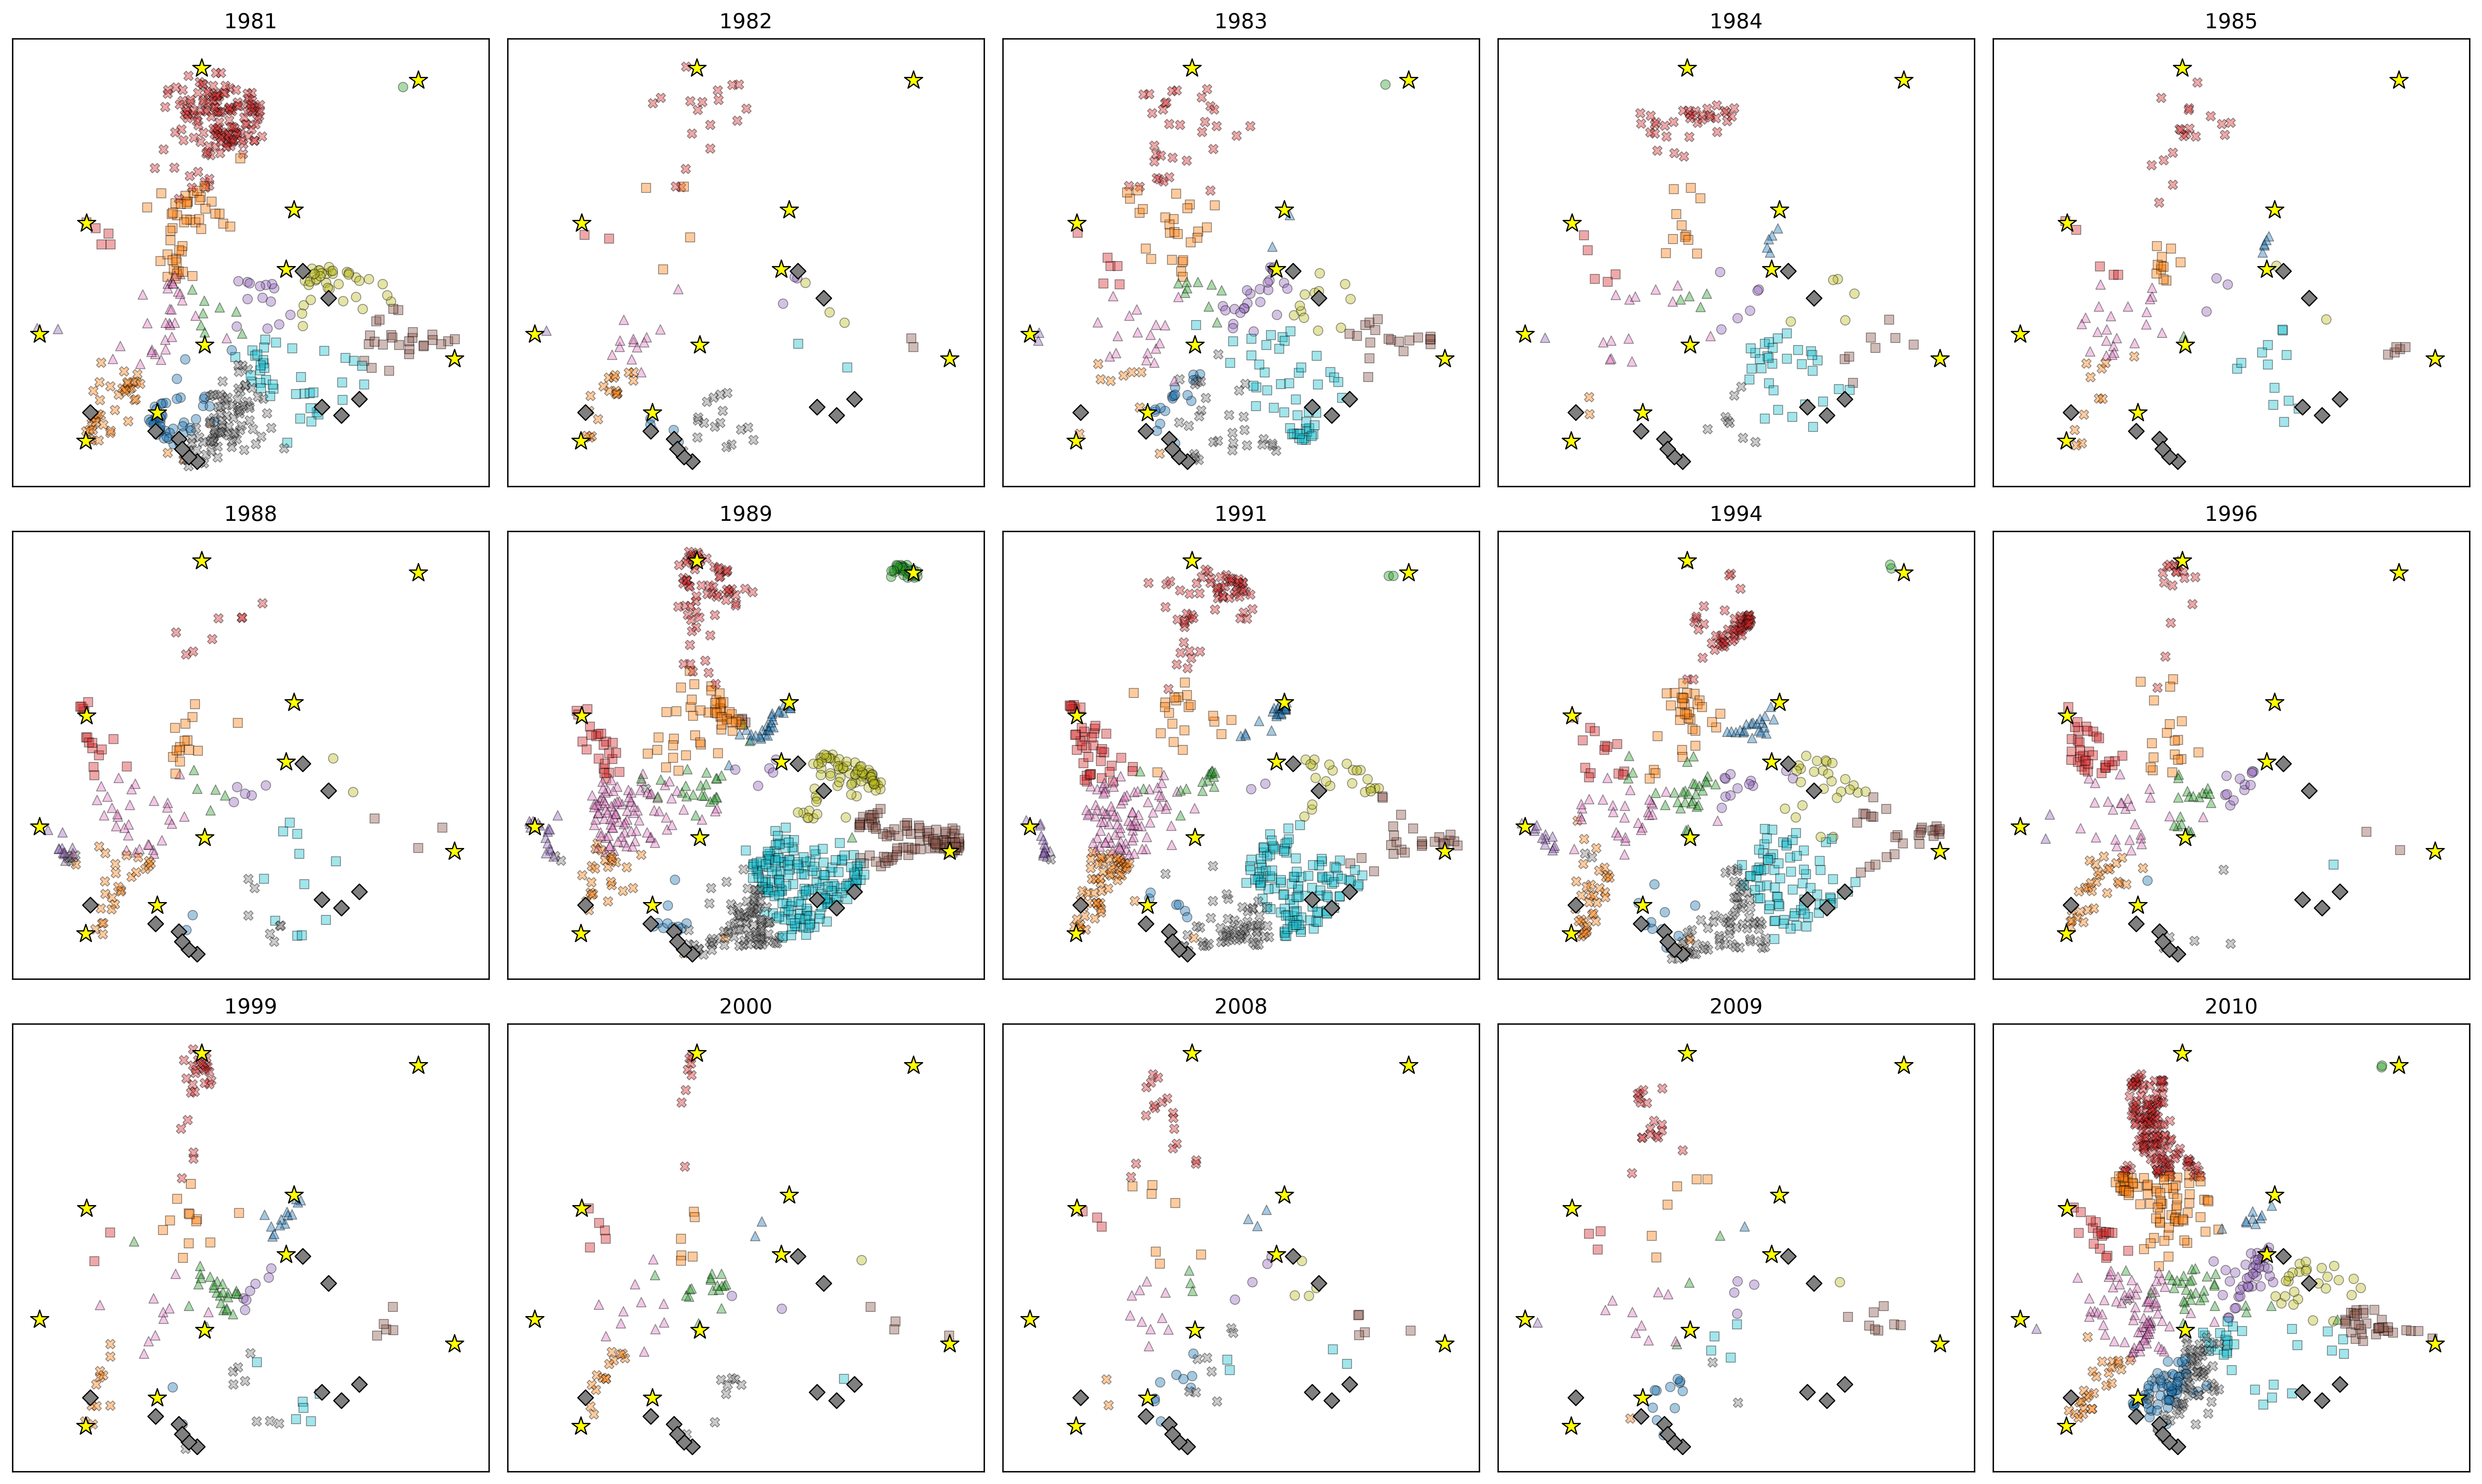

In [9]:
######### PLOTTING RESULT (CLUSTERING GRID BY YEAR) #########

import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib.lines as mlines

# ---- USER INPUT ----
years_to_display = [1981, 1982, 1983, 1984, 1985, 1988, 1989,
                    1991, 1994, 1996, 1999, 2000, 2008, 2009, 2010]

plotting_mode = "Clustering"
showing = True

print("\n# # # # # # # # # # # # # # # # # # # # # # # #")
print(f"Plotting mode : {plotting_mode}")
print(f"Years displayed : {years_to_display}")

# ---- YEAR ARRAY ----
years_array = np.asarray(years_list).astype(int).ravel()

# ---- CLUSTER COLORS ----
particle_color, particle_marker, legend_elements = Functions.clustering_color(
    clusters,
    nmb_clusters,
    name_clusters
)

# ---- SAFE LENGTH ----
n_particles = min(
    len(final_result_clustering),
    len(particle_color),
    len(particle_marker),
    len(years_array)
)

# ---- GRID SETUP ----
years_to_display = np.asarray(years_to_display)

n_years = len(years_to_display)
ncols = 5
nrows = math.ceil(n_years / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols,4*nrows), dpi=300, sharex=True, sharey=True)
axes = axes.flatten()

# ========= PLOTTING =========

for i, year in enumerate(years_to_display):

    ax = axes[i]

    year_mask = (years_array[:n_particles] == year)
    indices = np.where(year_mask)[0]

    # ---- REFERENCE POINTS ----
    for j in range(len(final_result_reference[:, 1])):

        if type_list_reference[j] == 'M':
            ax.scatter(
                final_result_reference[j,1],
                final_result_reference[j,0],
                color='grey',
                marker='D',
                s=40,
                edgecolor='black',
                linewidth=0.7,
                zorder=20
            )

        elif type_list_reference[j] == 'ELMT':
            ax.scatter(
                final_result_reference[j,1],
                final_result_reference[j,0],
                color='yellow',
                marker='*',
                s=120,
                edgecolor='black',
                linewidth=0.7,
                zorder=20
            )

    # ---- CLUSTERED PARTICLES ----
    for j in indices:
        ax.scatter(
            final_result_clustering[j,1],
            final_result_clustering[j,0],
            color=particle_color[j],
            marker=particle_marker[j],
            s=30,
            alpha=0.4,
            edgecolor='black',
            linewidth=0.5
        )

    ax.set_title(str(year))
    ax.set_xticks([])
    ax.set_yticks([])

# ---- HIDE UNUSED SUBPLOTS ----
for j in range(n_years, len(axes)):
    axes[j].axis("off")

# ========= LEGEND (ONLY ONCE) =========

legend_elements_full = legend_elements + [

    mlines.Line2D(
        [0], [0],
        marker='D',
        linestyle='None',
        markerfacecolor='grey',
        markeredgecolor='black',
        markersize=8,
        label="Mineral"
    ),

    mlines.Line2D(
        [0], [0],
        marker='*',
        linestyle='None',
        markerfacecolor='yellow',
        markeredgecolor='black',
        markersize=10,
        label="Pure element"
    )
]



plt.tight_layout()

if showing:
    plt.show()

plt.close(fig)

In [ ]:
############################################
####### Export statistics to Excel #########
############################################
type_list_uncertain_clustering = type_list_uncertain[(type_list.flatten() != "M") & (type_list.flatten() != "ELMT")]
clusters = np.array(clusters).ravel()
years_list_clustering = np.array(years_list_clustering).ravel()
type_list_uncertain_clustering = np.array(type_list_uncertain_clustering).ravel()
saving_path = f"../../Data/Data_all/Clustering/Clusters_variables/Catalog{catalog_id}/euclidean/"
output_file =  saving_path+"clusters_statistics.xlsx"

# Particle types you want in the output
wanted_types = ["TCA", "TCA?", "AOS", "AOS?", "TCN", "TCN?", "C", "C?", "NA"]

# Function to compute stats for a given subset
# Function to compute stats for a given subset
def compute_cluster_table(clusters_subset, types_subset):

    unique_clusters, cluster_counts = np.unique(clusters_subset, return_counts=True)

    rows = []

    for cl, size in zip(unique_clusters, cluster_counts):

        row = {
            "Cluster name": name_clusters[cl],
            "Total particles": size
        }

        # Compute type counts inside this cluster
        cluster_mask = clusters_subset == cl
        types_in_cluster = types_subset[cluster_mask]

        for t in wanted_types:
            count_t = np.sum(types_in_cluster == t)
            row[t] = count_t

        rows.append(row)

    df = pd.DataFrame(rows)

    # -------------------------------
    # Add TOTAL row (column totals)
    # -------------------------------
    total_row = {}

    for col in df.columns:
        if col == "Cluster name":
            total_row[col] = "Total"
        else:
            total_row[col] = df[col].sum()

    df = pd.concat([df, pd.DataFrame([total_row])], ignore_index=True)

    return df

# Create Excel writer
with pd.ExcelWriter(output_file, engine="openpyxl") as writer:

    # ---------- Final sheet: All years ----------
    df_year = compute_cluster_table(clusters, type_list_uncertain_clustering)
    df_year.to_excel(writer, sheet_name="All_years", index=False)

    # ---------- One sheet per year ----------
    unique_years = np.unique(years_list_clustering)

    for year in unique_years:

        # Select particles from that year
        year_mask = years_list_clustering == year

        clusters_year = clusters[year_mask]
        types_year = type_list_clustering[year_mask]

        df_year = compute_cluster_table(clusters_year, types_year)

        # Write sheet
        sheet_name = f"Year_{year}"
        df_year.to_excel(writer, sheet_name=sheet_name, index=False)
        print(f"Year {year} processed")
    
print(f"\nExcel file successfully created: {output_file}")

Year 1981 processed
Year 1982 processed
Year 1983 processed
Year 1984 processed
Year 1985 processed
Year 1988 processed
Year 1989 processed
Year 1991 processed
Year 1994 processed
Year 1996 processed
Year 1999 processed
Year 2000 processed
Year 2008 processed
Year 2009 processed
Year 2010 processed

Excel file successfully created: ../../../Data_all/Clustering/Clusters_variables/Catalog1to18/euclidean/clusters_statistics.xlsx


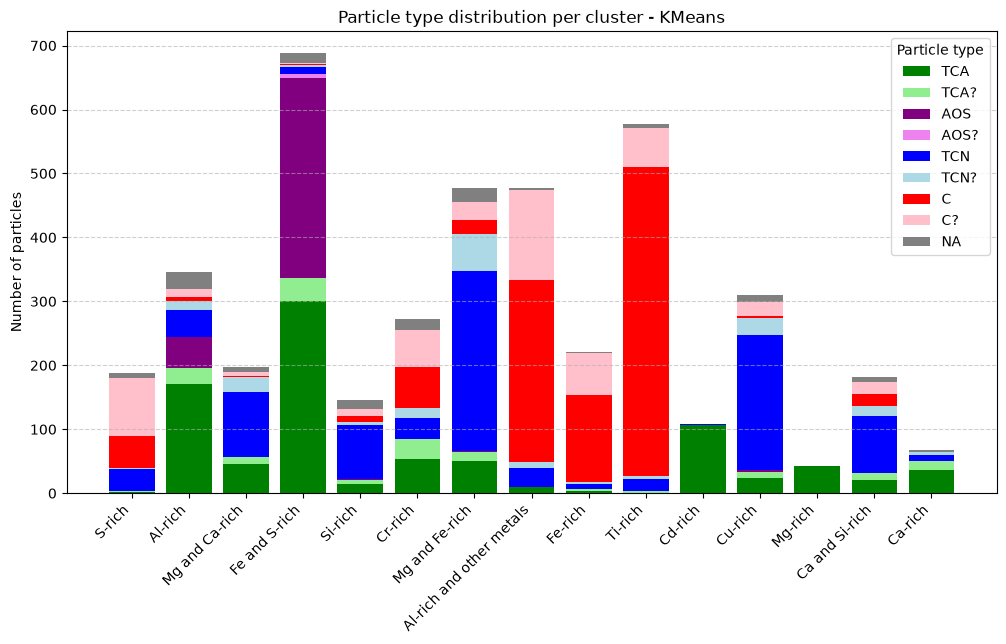

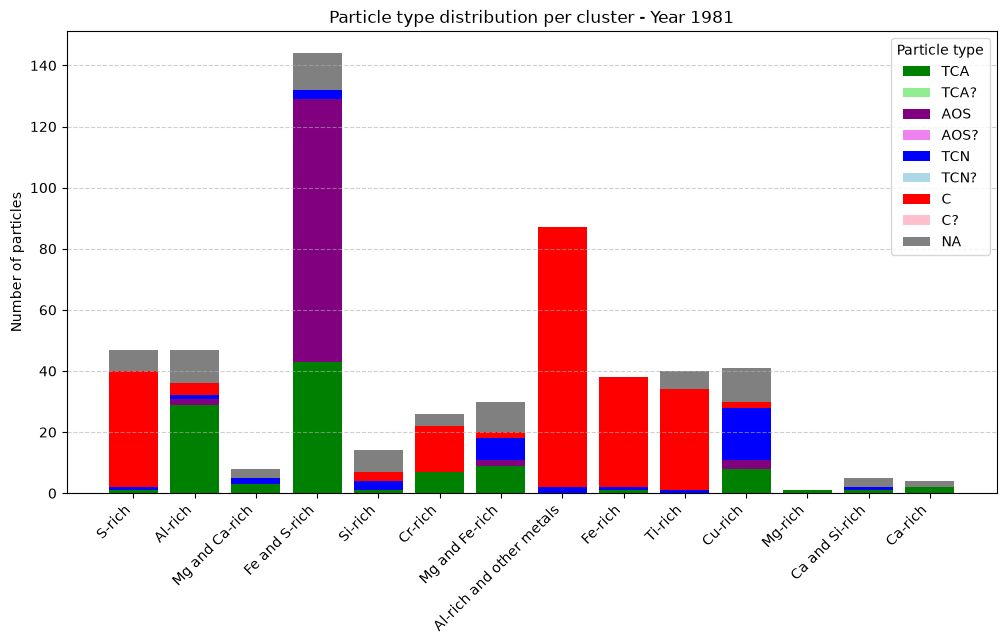

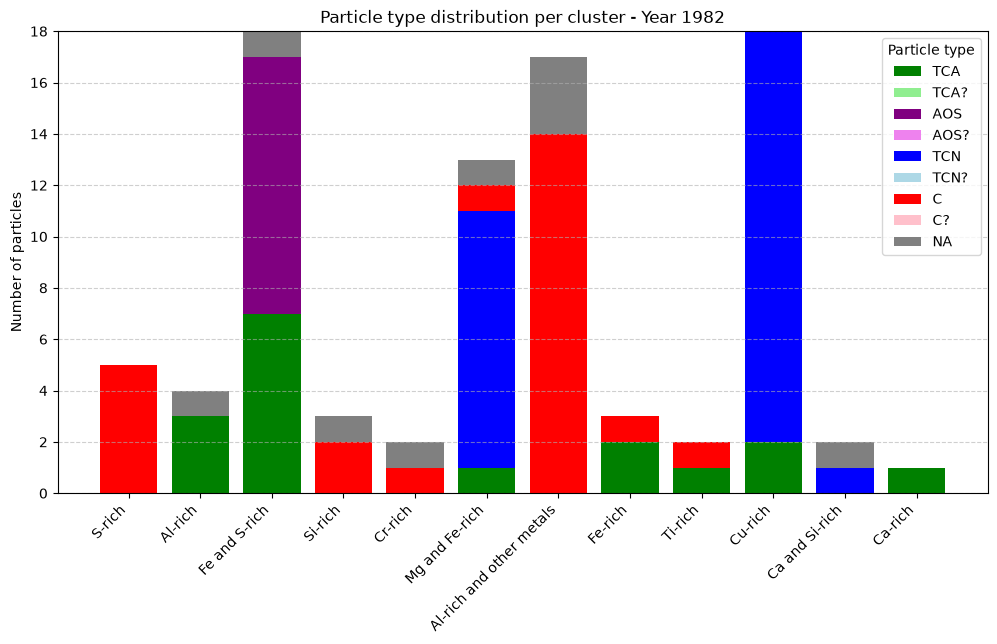

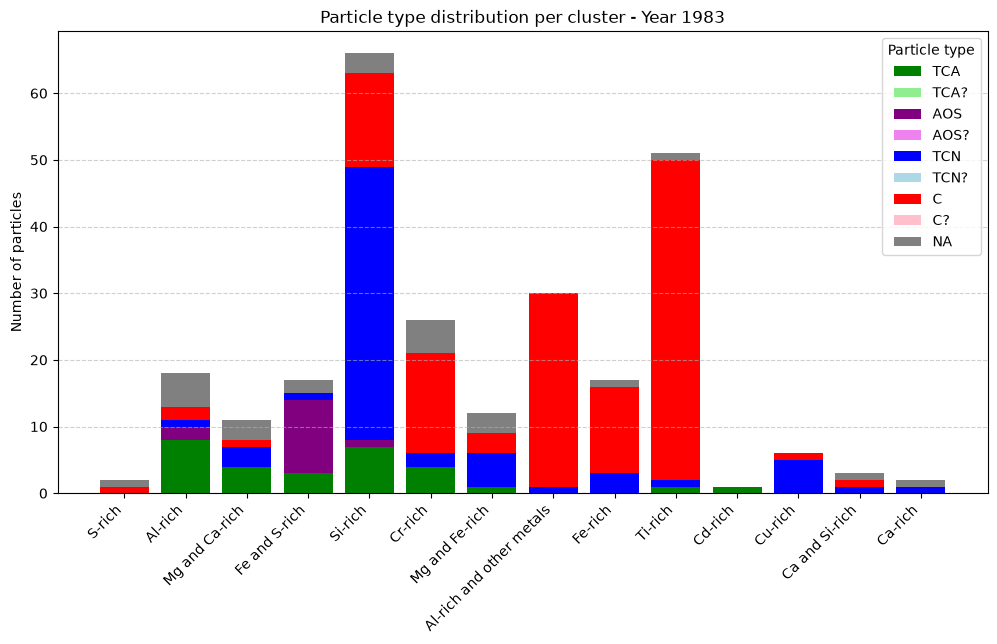

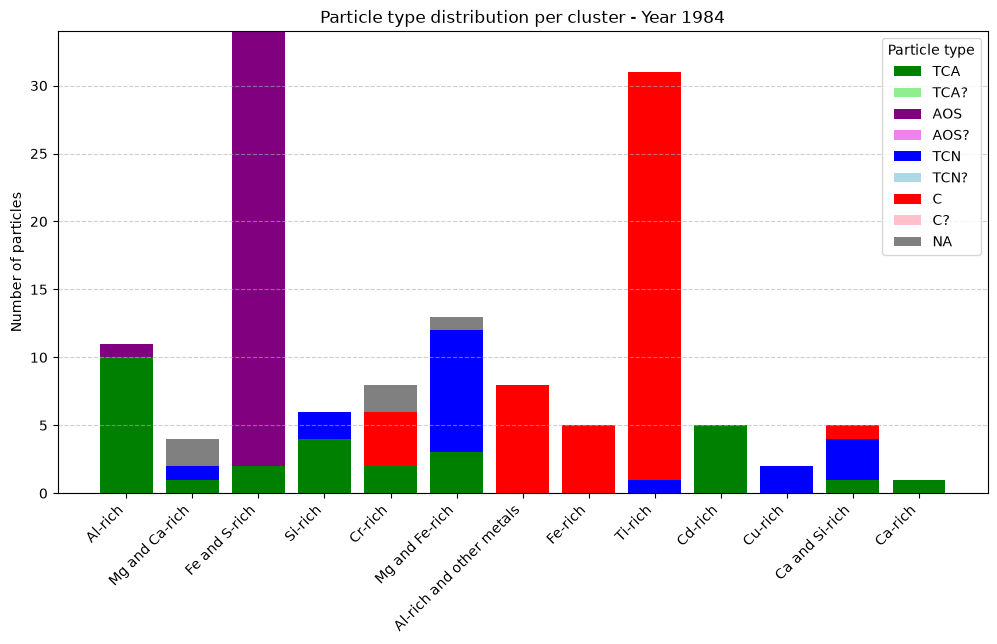

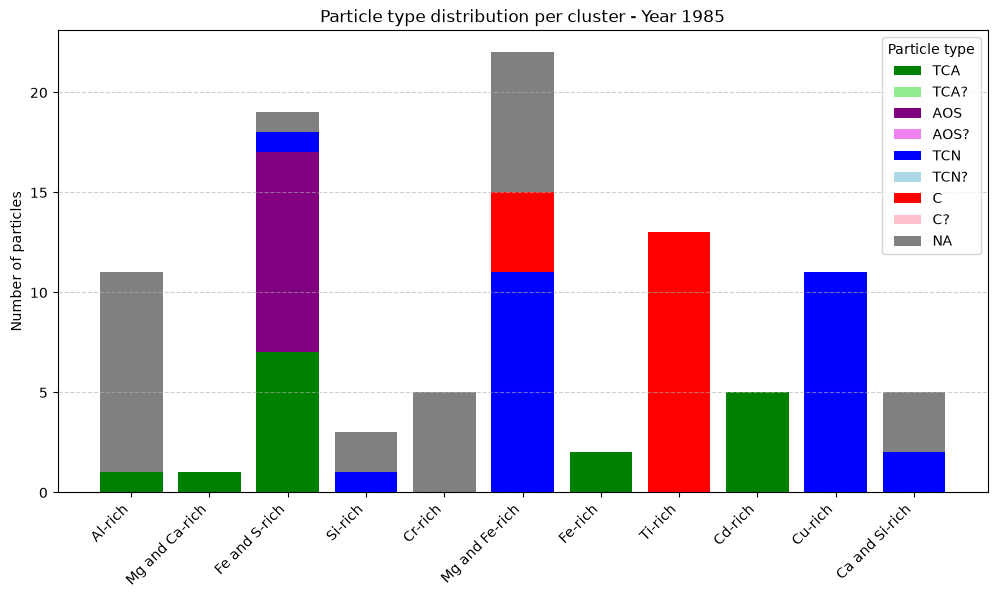

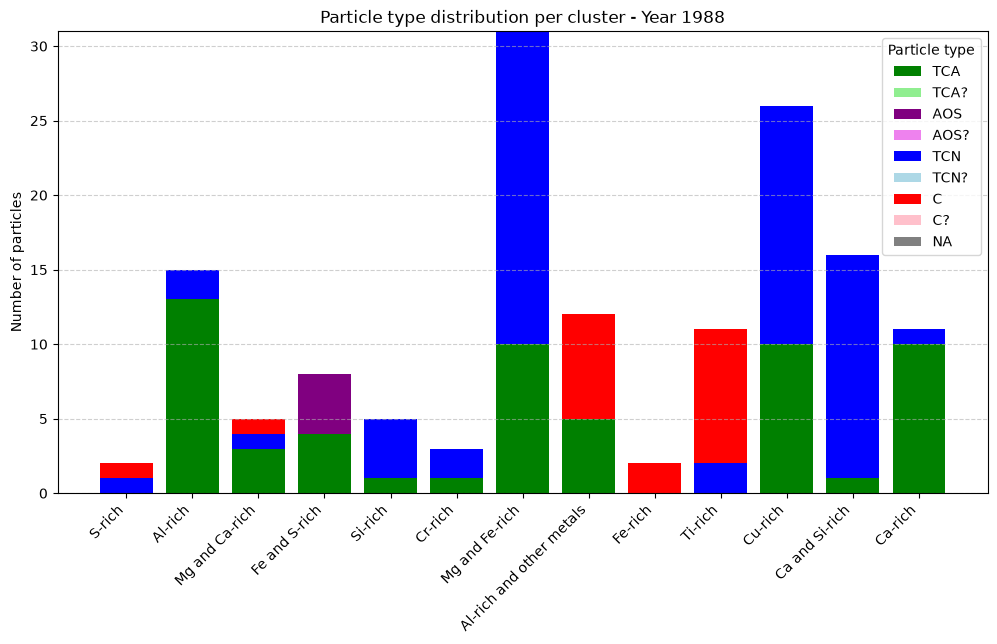

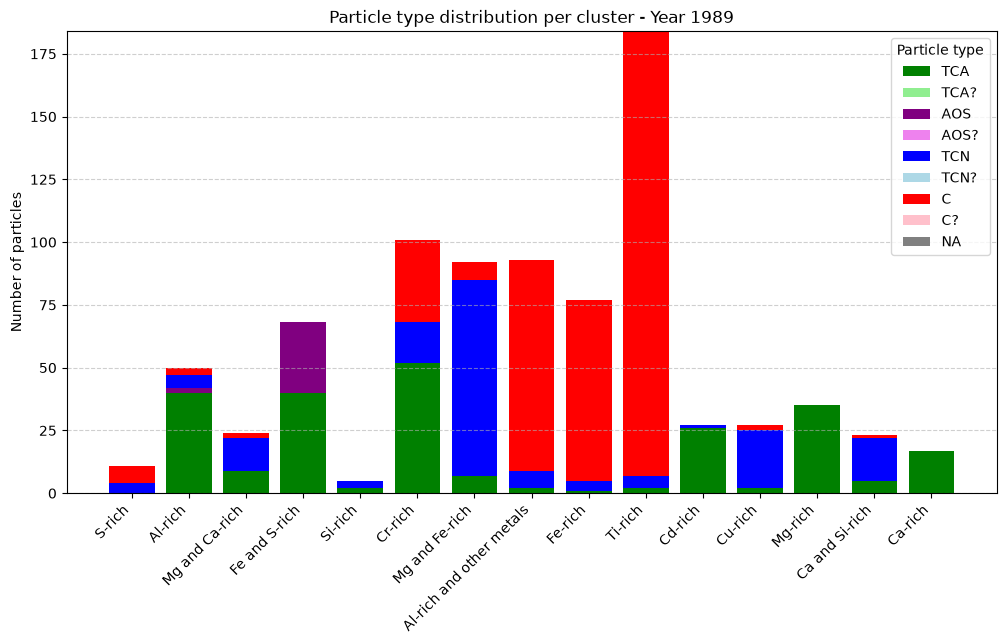

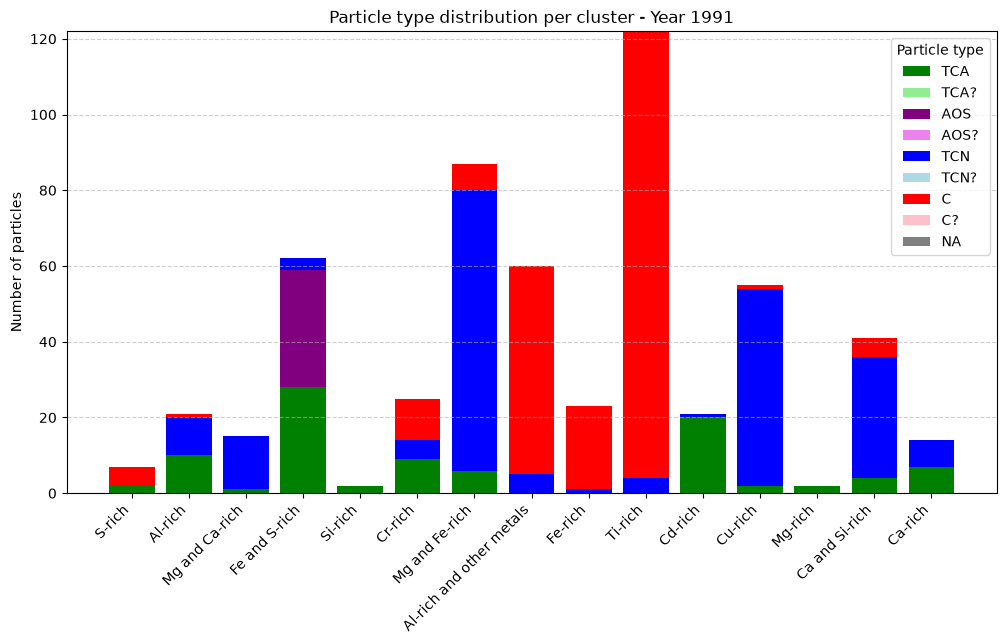

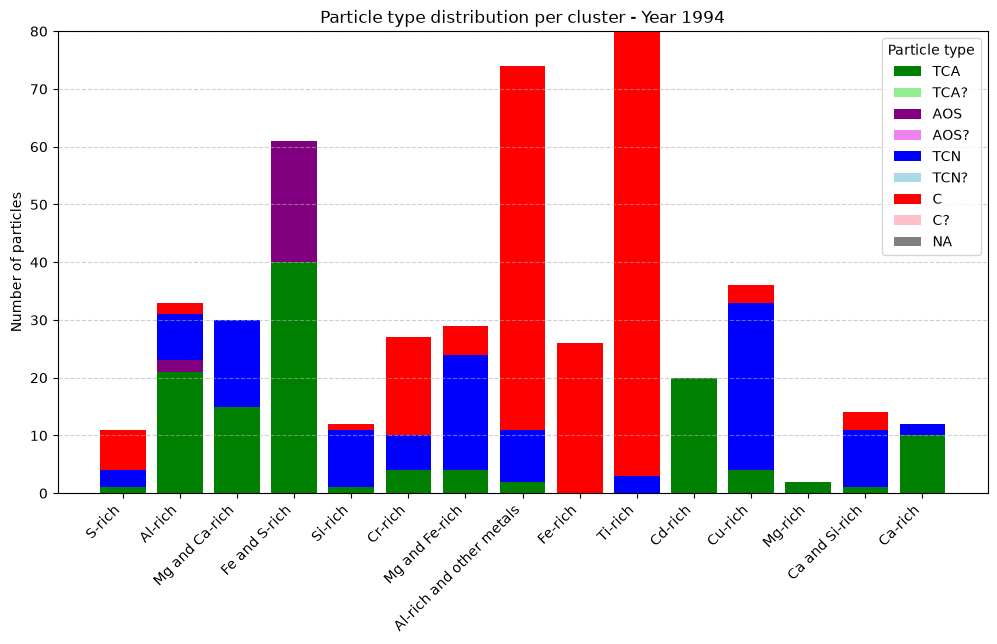

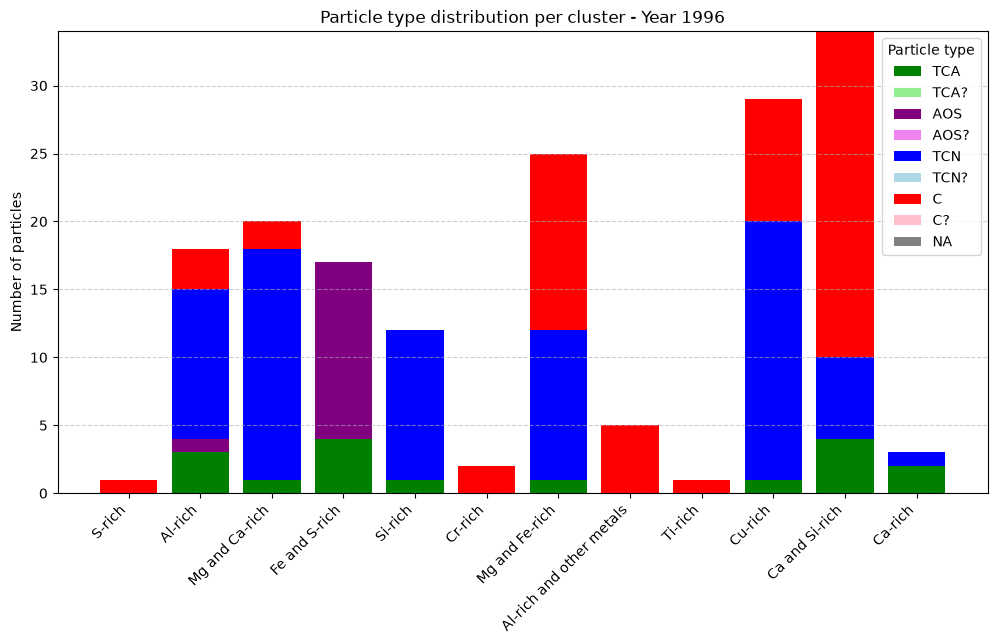

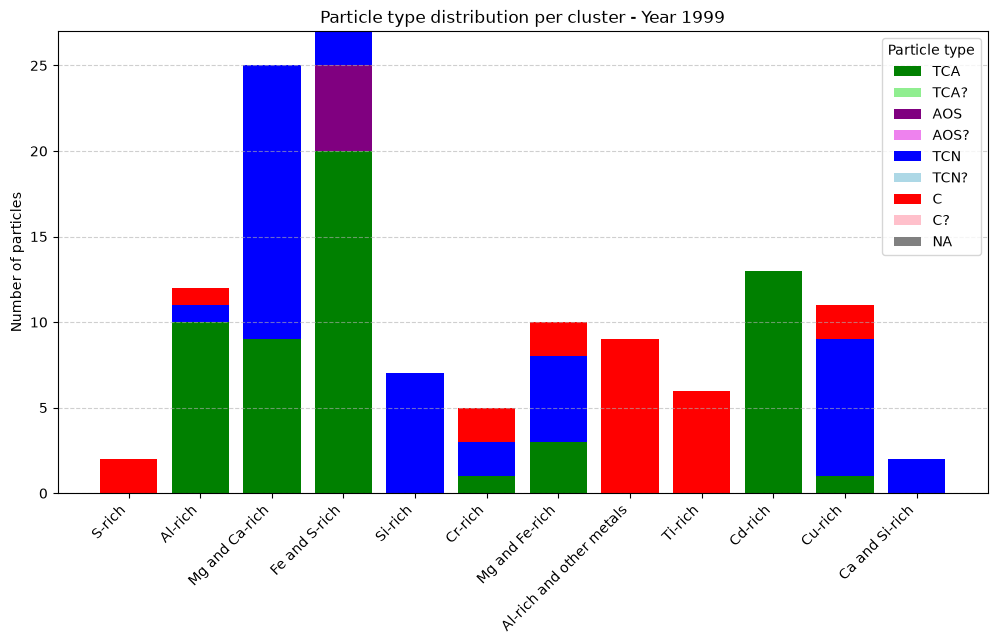

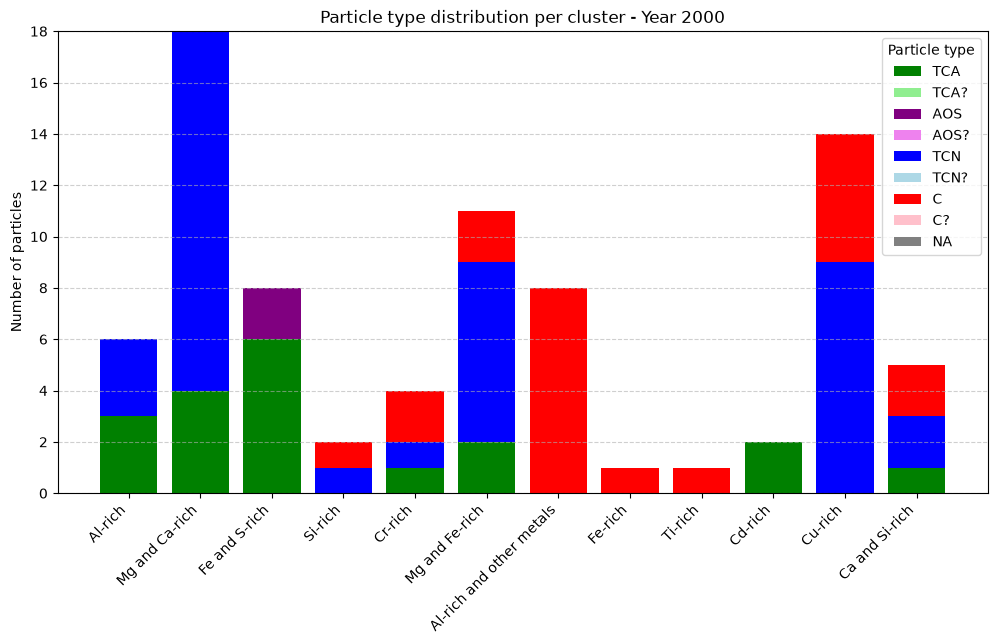

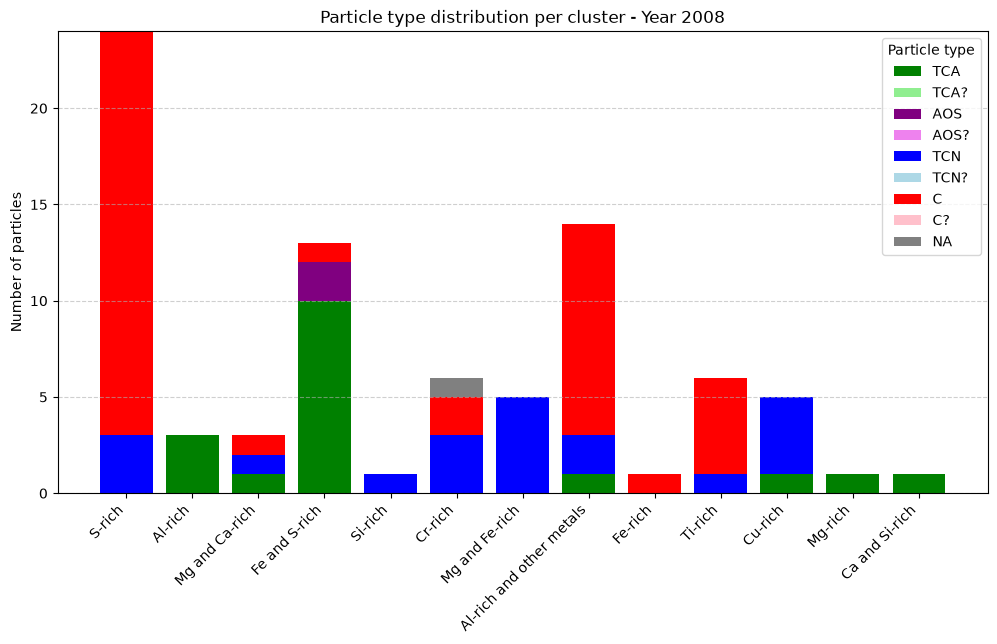

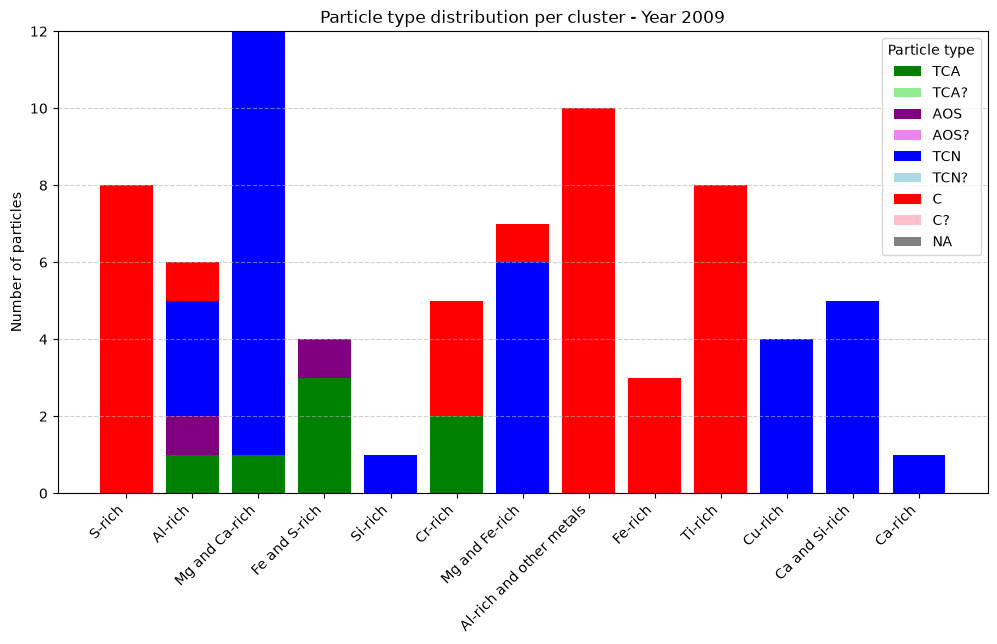

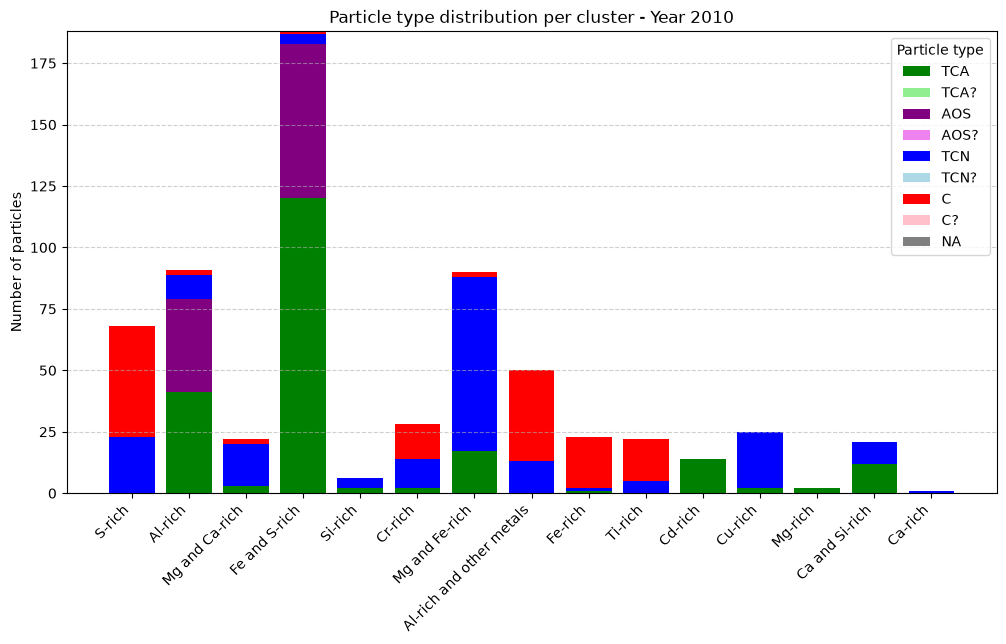

In [12]:
############################################
####### Plot particle type histograms ######
############################################

# Excel file generated previously
excel_file = saving_path+"clusters_statistics.xlsx"

# Particle types stored in the file
wanted_types = ["TCA", "TCA?", "AOS", "AOS?", "TCN", "TCN?", "C", "C?", "NA"]

type_colors = {
    "TCA": "green",
    "TCA?": "lightgreen",
    "AOS": "purple",
    "AOS?": "violet",
    "TCN": "blue",
    "TCN?": "lightblue",
    "C": "red",
    "C?": "pink",
    "NA": "grey"
}

# Load Excel file
xls = pd.ExcelFile(excel_file)

# ---- Select all relevant sheets ----
sheets_to_plot = ["All_years"] + [
    s for s in xls.sheet_names if s.startswith("Year_")
]

# Sort yearly sheets (keep All_years first)
sheets_to_plot = ["All_years"] + sorted([s for s in sheets_to_plot if s.startswith("Year_")],key=lambda x: int(x.split("_")[1]))

# ---- Loop over each sheet ----
for sheet_name in sheets_to_plot:

    # Define plot title label
    if sheet_name == "All_years":
        label = clustering_method
    else:
        year = sheet_name.split("_")[1]
        label = f"Year {year}"

    # Read sheet
    df = pd.read_excel(excel_file, sheet_name=sheet_name)

    # Cluster indices on x-axis
    clusters_names = df["Cluster name"].values[:-1]  # Exclude total row
    

    # --- Prepare stacked histogram plot ---
    plt.figure(figsize=(12, 6))

    # Bottom accumulator for stacking
    bottom = np.zeros(len(clusters_names))

    # Plot each particle type as stacked bars
    for ptype in wanted_types:

        values = df[ptype].values[:-1]  # Exclude total row

        plt.bar(
            clusters_names,
            values,
            bottom=bottom,
            label=ptype,
            color=type_colors[ptype]
        )

        # Update stacking baseline
        bottom += values

    # Labels and title
    #plt.xlabel("Cluster index")
    plt.ylabel("Number of particles")
    plt.title(f"Particle type distribution per cluster - {label}")

    plt.xticks(clusters_names,clusters_names, rotation=45, ha='right')
    plt.legend(title="Particle type")

    plt.grid(axis="y", linestyle="--", alpha=0.6)

    plt.show()

    #Other = Noisy (or light elements)
    #Label the clusters instead of the numbers of clusters


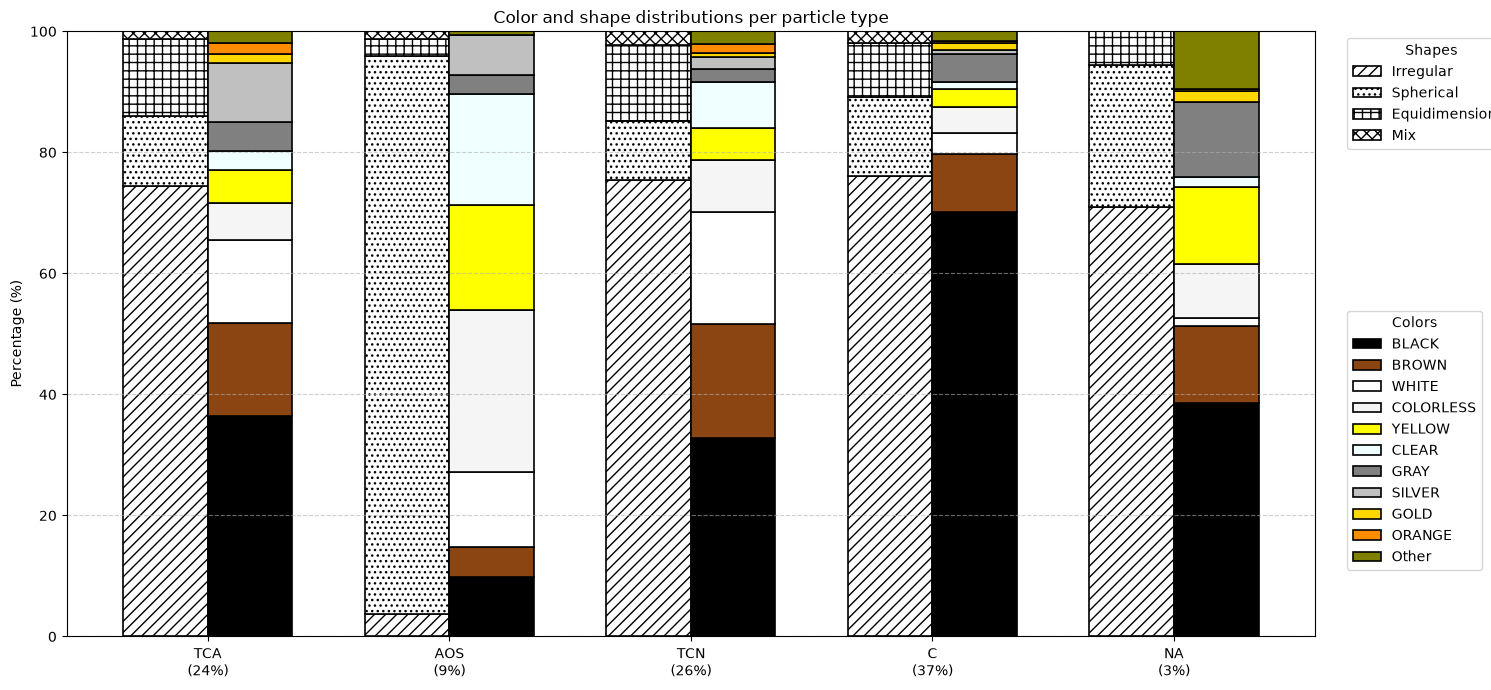

In [13]:
#########################################################
####### Plot the shapes and colors of particles #########
#########################################################

# ---------------- USER OPTION ----------------
MAX_LEGEND_COLORS = 11   # includes "Other"
# --------------------------------------------

# Flatten arrays
types  = np.array(type_list_clustering).ravel()
shapes = np.array(shapes_list_clustering).ravel()
colors_raw = np.array(colors_list_clustering).ravel()

# Particle types
wanted_types = ["TCA", "AOS", "TCN", "C", "NA"]

# =======================================================
#                PART 1 — SHAPES
# =======================================================

shape_categories = {
    "I": "Irregular",
    "S": "Spherical",
    "E": "Equidimensional",
    "Mix": "Mix"
}

# Hatch patterns (B/W legend)
shape_hatches = {
    "Irregular": "///",
    "Spherical": "...",
    "Equidimensional": "++",
    "Mix": "xxx"
}

# Count shapes per type
shape_counts = pd.DataFrame(
    0,
    index=wanted_types,
    columns=shape_categories.values()
)

for t in wanted_types:

    mask_type = types == t
    shapes_type = shapes[mask_type]

    count_I = np.sum([str(s) == "I" for s in shapes_type])
    count_E = np.sum([str(s) == "E" for s in shapes_type])
    count_S = np.sum([str(s) == "S" for s in shapes_type])

    count_Mix = len(shapes_type) - (count_I + count_E + count_S)

    shape_counts.loc[t, "Irregular"] = count_I
    shape_counts.loc[t, "Equidimensional"] = count_E
    shape_counts.loc[t, "Spherical"] = count_S
    shape_counts.loc[t, "Mix"] = count_Mix

# Convert to percentages
shape_percent = shape_counts.div(shape_counts.sum(axis=1), axis=0) * 100


# =======================================================
#                PART 2 — COLORS
# =======================================================

color_names = {
    "AM": "AMBER",
    "BK": "BLACK",
    "BL": "BLUE",
    "BR": "BROWN",
    "BZ": "BRONZE",
    "CL": "CLEAR",
    "CS": "COLORLESS",
    "GD": "GOLD",
    "GN": "GREEN",
    "GR": "GRAY",
    "OR": "ORANGE",
    "RD": "RED",
    "RU": "RUBY",
    "SI": "SILVER",
    "VI": "VIOLET",
    "WH": "WHITE",
    "YL": "YELLOW"
}

plot_colors = {
    "AMBER": "orange",
    "BLACK": "black",
    "BLUE": "blue",
    "BROWN": "saddlebrown",
    "BRONZE": "peru",
    "CLEAR":"#F0FFFF",#"lightgray",
    "COLORLESS": "whitesmoke",
    "GOLD": "gold",
    "GREEN": "green",
    "GRAY": "gray",
    "ORANGE": "darkorange",
    "RED": "red",
    "RUBY": "darkred",
    "SILVER": "silver",
    "VIOLET": "violet",
    "WHITE": "white",
    "YELLOW": "yellow",
    "Other": "olive"
}

# =======================================================
#   Extract fractional colors per particle (UPDATED)
# =======================================================

particle_colors = []

for entry in colors_raw:

    if pd.isna(entry):
        particle_colors.append([])
        continue

    parts = str(entry).split("_")

    # Keep only valid color codes
    valid_codes = [c for c in parts if c in color_names]

    if len(valid_codes) == 0:
        particle_colors.append([])
        continue

    # Fraction per color = 1 / number of codes
    frac = 1 / len(valid_codes)

    # Store full names with weights
    weighted_colors = [(color_names[c], frac) for c in valid_codes]

    particle_colors.append(weighted_colors)


# =======================================================
#   Global weighted frequency (UPDATED)
# =======================================================

global_counts = Counter()

for particle in particle_colors:
    for name, weight in particle:
        global_counts[name] += weight


# Keep most common colors
N_KEEP = MAX_LEGEND_COLORS - 1
most_common = [c for c, _ in global_counts.most_common(N_KEEP)]

final_categories = most_common + ["Other"]


# =======================================================
#   Count fractional colors per type (UPDATED)
# =======================================================

color_counts = pd.DataFrame(
    0.0,
    index=wanted_types,
    columns=final_categories
)

for t in wanted_types:

    mask_type = types == t
    colors_type = np.array(particle_colors, dtype=object)[mask_type]

    for particle in colors_type:
        for c, weight in particle:

            if c in most_common:
                color_counts.loc[t, c] += weight
            else:
                color_counts.loc[t, "Other"] += weight


# Convert to percentages
color_percent = color_counts.div(color_counts.sum(axis=1), axis=0) * 100


# =======================================================
#                PART 3 — X LABELS (% types)
# =======================================================

total_particles_all = len(types)

type_percentages = {}
for t in wanted_types:
    n_type = np.sum(types == t)
    type_percentages[t] = (n_type / total_particles_all) * 100

x_labels = [f"{t}\n({type_percentages[t]:.0f}%)" for t in wanted_types]


# =======================================================
#                PART 4 — PLOT BOTH (2 LEGENDS)
# =======================================================

plt.figure(figsize=(15, 7))

x = np.arange(len(wanted_types))
width = 0.35   # bar width

# Store legend handles separately
shape_handles = []
color_handles = []

# ---------- SHAPE BARS (left) ----------
bottom = np.zeros(len(wanted_types))

for shape_label in shape_categories.values():

    values = shape_percent[shape_label].values

    bars = plt.bar(
        x - width/2,
        values,
        width,
        bottom=bottom,
        label=shape_label,
        color="white",
        edgecolor="black",
        hatch=shape_hatches[shape_label],
        linewidth=1.2
    )

    shape_handles.append(bars[0])
    bottom += values


# ---------- COLOR BARS (right) ----------
bottom = np.zeros(len(wanted_types))

for col in final_categories:

    values = color_percent[col].values

    if col == "Other":
        bars = plt.bar(
            x + width/2,
            values,
            width,
            bottom=bottom,
            label="Other",
            color="olive",
            edgecolor="black",
            #hatch="///",
            linewidth=1.2
        )
    else:
        bars = plt.bar(
            x + width/2,
            values,
            width,
            bottom=bottom,
            label=col,
            color=plot_colors[col],
            edgecolor="black",
            linewidth=1.2
        )

    color_handles.append(bars[0])
    bottom += values


# ---------- AXIS FORMATTING ----------
plt.xticks(x, x_labels)
plt.ylabel("Percentage (%)")
plt.ylim(0, 100)

plt.title("Color and shape distributions per particle type")
plt.grid(axis="y", linestyle="--", alpha=0.6)


# =======================================================
#                TWO SEPARATE LEGENDS
# =======================================================

legend1 = plt.legend(
    handles=shape_handles,
    labels=list(shape_categories.values()),
    title="Shapes",
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

plt.gca().add_artist(legend1)

plt.legend(
    handles=color_handles,
    labels=final_categories,
    title="Colors",
    loc="upper left",
    bbox_to_anchor=(1.02, 0.55)
)

plt.tight_layout()
plt.show()


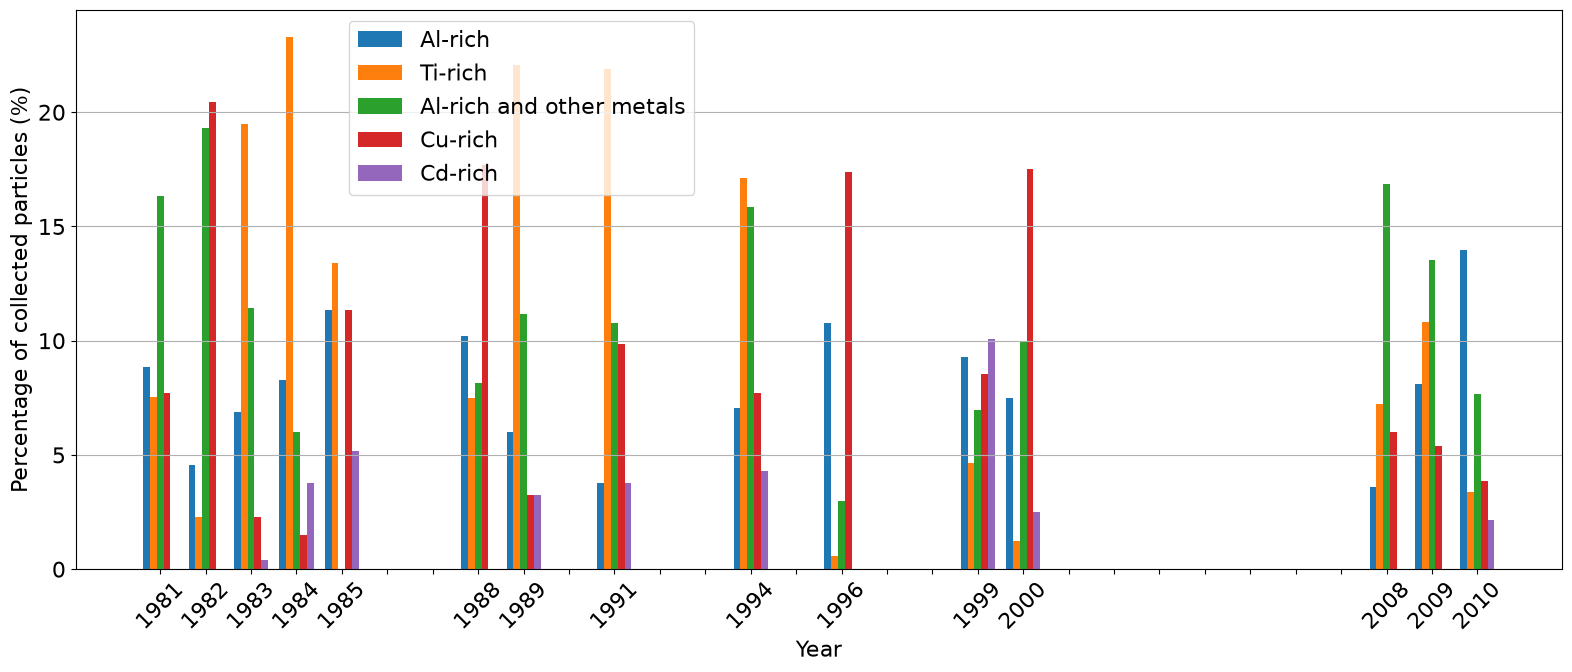

In [14]:
# ---------------- Plotting as one histogram ----------------

############################################
####### Plot cluster evolution vs time #####
############################################

# Clusters we want to track (note: Excel cluster indices start at 1)
clusters_to_plot = ["Al-rich","Ti-rich","Al-rich and other metals","Cu-rich","Cd-rich"]#[3,2,8,10,12]

# Open the Excel file you just created
excel_file = saving_path+"clusters_statistics.xlsx"
xls = pd.ExcelFile(excel_file)

# Extract the years from sheet names like "Year_2010"
year_sheets = [s for s in xls.sheet_names if s.startswith("Year_")]

# Sort sheets by year
years = sorted([int(s.split("_")[1]) for s in year_sheets])

# Store results: one list per cluster
cluster_counts = {cl: [] for cl in clusters_to_plot}
sum_counts = []

# Loop over each year sheet
for year in years:
    sheet_name = f"Year_{year}"
    df = pd.read_excel(excel_file, sheet_name=sheet_name)

    # Total particles sum for selected clusters in this year
    total_selected = 0

    total_count = df["Total particles"].values[-1]  # from "Total" row

    for cl in clusters_to_plot:
        # Find the row corresponding to this cluster
        row = df[df["Cluster name"] == cl]

        if not row.empty:
            value = row["Total particles"].values[0]
        else:
            value = 0  # cluster not present that year

        value = 100 * value / total_count  # convert to fraction of total particles

        cluster_counts[cl].append(value)
        total_selected += value

    sum_counts.append(total_selected)

# Ensure all text elements use fontsize 16
plt.rcParams.update({'font.size': 16})

plt.figure(figsize=(16, 7))  # Augmentation de la largeur pour mieux espacer les années

# Ajustement de la largeur des barres et de l'espacement
width = 0.3  # Légèrement plus large que précédemment
group_spacing = 2  # Espacement accru entre les années

# --- Create a complete yearly grid ---
all_years = np.arange(min(years), max(years) + 1)

# Map original years to x positions
x = np.arange(len(all_years)) * group_spacing

# Dictionary to locate each year index
year_to_idx = {year: idx for idx, year in enumerate(all_years)}

# Plot each cluster as bars
for i, cl in enumerate(clusters_to_plot):
    # Initialize with zeros for missing years
    values = np.zeros(len(all_years))

    # Fill existing data into correct year positions
    for j, yr in enumerate(years):
        idx = year_to_idx[yr]
        values[idx] = cluster_counts[cl][j]

    plt.bar(
        x + i * width,
        values,
        width=width,  # Utilisation de la nouvelle largeur
        label=clusters_to_plot[i]
    )

# --- Show ticks every year, but labels only where data exists ---
tick_positions = x + width * (len(clusters_to_plot) - 1) / 2
tick_labels = [str(y) if y in years else "" for y in all_years]

plt.xticks(
    tick_positions,
    tick_labels,
    rotation=45,
    fontsize=16
)

plt.xlabel("Year", fontsize=16)
plt.ylabel("Percentage of collected particles (%)", fontsize=16)

plt.legend(
    fontsize=16,
    bbox_to_anchor=(0.3, 1),  # Positionne la légende à droite et en haut
    loc='upper center', 
    fancybox=True         # Ancrage par rapport à bbox_to_anchor
    #borderaxespad=0.            # Supprime l'espacement supplémentaire
)
plt.grid(axis="y")

plt.tight_layout()
plt.show()

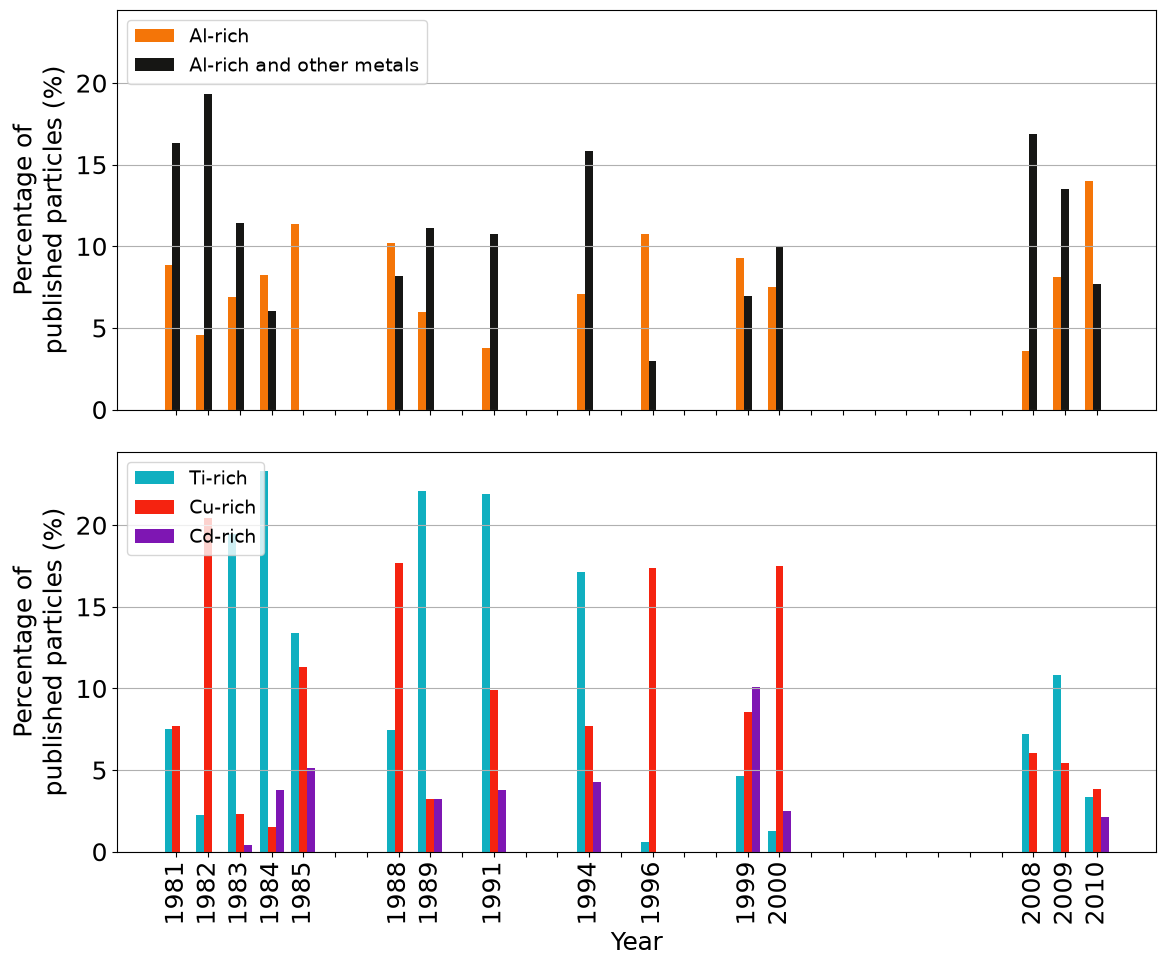

In [15]:
# ---------------- Plotting as Two Histograms ----------------

import numpy as np
import matplotlib.pyplot as plt

# Ensure all text elements use fontsize 18
plt.rcParams.update({'font.size': 18})

# Groups to separate
top_groups = ["Al-rich", "Al-rich and other metals"]
bottom_groups = [cl for cl in clusters_to_plot if cl not in top_groups]

# ----------------------------
# DÉFINITION DES COULEURS
# ----------------------------
# Couleurs pour les groupes du haut (top_groups)
top_colors = {
    "Al-rich": "#F47508",                
    "Al-rich and other metals": "#161614"
}

# Couleurs pour les groupes du bas (bottom_groups)
# Exemple : si bottom_groups contient ["Group1", "Group2", "Group3", ...]
bottom_colors = {
    "Ti-rich": "#10AFC0",
    "Cu-rich": "#F52310",
    "Cd-rich": "#7E16B3"
}

# Si bottom_groups contient d'autres noms, ajustez bottom_colors en conséquence.
# Par défaut, si une clé n'est pas trouvée, une couleur par défaut sera utilisée.
default_color = "#aec7e8"  # Bleu clair par défaut

# ----------------------------
# Plot parameters
width = 0.5
group_spacing = 2

# --- Create a complete yearly grid ---
all_years = np.arange(min(years), max(years) + 1)

# Map original years to x positions
x = np.arange(len(all_years)) * group_spacing
year_to_idx = {year: idx for idx, year in enumerate(all_years)}

# ---------- Determine common y-axis ----------
max_value = 0
for cl in clusters_to_plot:
    values = np.zeros(len(all_years))
    for j, yr in enumerate(years):
        values[year_to_idx[yr]] = cluster_counts[cl][j]
    max_value = max(max_value, np.max(values))

# ---------- Create figure ----------
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(12, 10),
    sharex=True,
    sharey=True
)

# ---------- Top histogram ----------
for i, cl in enumerate(top_groups):
    values = np.zeros(len(all_years))
    for j, yr in enumerate(years):
        values[year_to_idx[yr]] = cluster_counts[cl][j]

    # Utiliser la couleur définie dans top_colors ou une couleur par défaut
    color = top_colors.get(cl, default_color)

    ax1.bar(
        x + i * width,
        values,
        width=width,
        label=cl,
        color=color  # Couleur personnalisée
    )

ax1.set_ylabel("Percentage of\npublished particles (%)")
ax1.set_ylim(0, max_value * 1.05)
ax1.grid(axis="y")
ax1.legend(loc="upper left", fontsize=14)

# ---------- Bottom histogram ----------
for i, cl in enumerate(bottom_groups):
    values = np.zeros(len(all_years))
    for j, yr in enumerate(years):
        values[year_to_idx[yr]] = cluster_counts[cl][j]

    # Utiliser la couleur définie dans bottom_colors ou une couleur par défaut
    color = bottom_colors.get(cl, default_color)

    ax2.bar(
        x + i * width,
        values,
        width=width,
        label=cl,
        color=color  # Couleur personnalisée
    )

# X-axis
tick_positions = x + width * (max(len(top_groups), len(bottom_groups)) - 1) / 2
tick_labels = [str(y) if y in years else "" for y in all_years]

ax2.set_xticks(tick_positions)
ax2.set_xticklabels(tick_labels, rotation=90)

ax2.set_xlabel("Year")
ax2.set_ylabel("Percentage of\npublished particles (%)")
ax2.set_ylim(0, max_value * 1.05)
ax2.grid(axis="y")
ax2.legend(loc="upper left", fontsize=14)

plt.tight_layout()
plt.show()

Evaluate the optimized number of clusters (time consuming !)

In [ ]:
######### Calculate between 2 and 20 clusters with K-Means #########
for nmb_clusters in range(2,21):
    clustering_method = "KMeans" # Or "BisectingKMeans" or "AgglomerativeClustering" or "SpectralClustering"

    metrics = "euclidean" # "euclidean" or "dtw" or "softdtw"
    centroids = False # "True" or "False" (creates a folder with the wanted number of closest spectra to each centroid cluster)
    centroid_number_average = 3 # The number of spectra near to the centroid you want to get
    clustering_status = "to_process" # Or "to_process" or "to_load" or "none" 
    print("\n# # # # # # # # # # # # # # # # # # # # # # # #")
    print(f"Clustering status : {clustering_status}")

    ## IF USING SELECTION clustering_status SHOULD BE to_load
    with_selection = False # Or False
    clusters_to_save = np.array([1,2,6,7,8,9,10,12,13])
    selected_nmb_clusters = 11

    # Split between references (pure elements and minerals) not to be clustered and spectra to be clustered
    spectra_list_clustering = spectra_list[(type_list.flatten() != "M") & (type_list.flatten() != "ELMT")]
    spectra_list_reference = spectra_list[(type_list.flatten() == "M") | (type_list.flatten() == "ELMT")]
    name_list_clustering = name_list[(type_list.flatten() != "M") & (type_list.flatten() != "ELMT")]
    name_list_reference = name_list[(type_list.flatten() == "M") | (type_list.flatten() == "ELMT")]
    final_result_clustering = final_result[(type_list.flatten() != "M") & (type_list.flatten() != "ELMT")]
    final_result_reference = final_result[(type_list.flatten() == "M") | (type_list.flatten() == "ELMT")]
    type_list_reference = type_list[(type_list.flatten() == "M") | (type_list.flatten() == "ELMT")]

    if metrics == "euclidean":
        # Clustering of data with K-Means : euclidean 
        saving_path_pkl_clusters = f"../../Data/Data_all/Clustering/Clusters_variables/Catalog{catalog_id}/euclidean/TSKMeans_{str(nmb_clusters)}clusters_euclidean.pkl"

    if metrics == "dtw":
        # Clustering of data with K-Means : dtw 
        saving_path_pkl_clusters = f"../../Data/Data_all/Clustering/Clusters_variables/Catalog{catalog_id}/dtw/TSKMeans_{str(nmb_clusters)}clusters_dtw.pkl"

    if metrics == "softdtw":
        # Clustering of data with K-Means : softdtw 
        saving_path_pkl_clusters = f"../../Data/Data_all/Clustering/Clusters_variables/Catalog{catalog_id}/softdtw/TSKMeans_{str(nmb_clusters)}clusters_softdtw.pkl"


    if clustering_status == "to_process":
        # If clustering needed to be calculated
        start_time = time.time()
        print("Number of clusters : " + str(nmb_clusters))
        print("Clustering metrics : " + metrics)

        k_means = TimeSeriesKMeans(n_clusters=nmb_clusters, metric=metrics, random_state=42, n_init=10, max_iter=25) #this method allows to define the metric
        #k_means = KMeans(n_clusters=nmb_clusters, random_state=42, n_init=10, max_iter=25, init='k-means++', verbose=1)
        clusters = k_means.fit_predict(spectra_list_clustering)
        joblib.dump(clusters, saving_path_pkl_clusters)

        elapsed_time = time.time() - start_time
        print("Total time with " + str(nmb_clusters) + " clusters : ", time.strftime("%H:%M:%S", time.gmtime(elapsed_time)))

        # Plotting the centroids if necessary
        if centroids == True:
            # Calculating the centroids and printing it
            centroids = Functions.centroids(spectra_list_clustering, name_list_clustering, clusters, nmb_clusters, centroid_number_average)
            print(centroids)

            ######### PLOTTING THE CENTROIDS #########
            title = f"{clustering_method}_{metrics}_{reduction_type}_{str(clustering_method)}_{str(nmb_clusters)}clust_Cat{catalog_id}"
            saving_path = f"../../Data/Data_all/Clustering/Graphiques/{reduction_type}/Catalog {catalog_id}/Clustering/{clustering_method}/{title}" 

            # Creating the directory if it doesn't exists
            for nmb in range(nmb_clusters):
                os.makedirs(f"{saving_path}/Cluster{str(nmb + 1)}", exist_ok=True)

            # Opening the global catalog
            with open(global_catalog_path, 'r') as csv_global:
                reader = csv.reader(csv_global)
                all_data = np.array([row for row in reader], dtype=str)[1:]

                particle_names = all_data[:,0]
                catalog_numbers = all_data[:,1]

            particle_names = np.array(particle_names, dtype=str)
            catalog_numbers = np.array(catalog_numbers, dtype=str)

            cluster_index = 0

            for names in centroids['Closest spectra name'].values:
                for i in range(centroid_number_average):
                    name = names[i]
                    catalog_number = str(catalog_numbers[np.where(name == particle_names)][0])
                    source_path = f"../../Data/Data_all/Catalog{catalog_number}/Catalog{catalog_number}_pdf_checked/{name}.pdf"
                    destination_path = f"{saving_path}/Cluster{cluster_index + 1}/Spectra_image_average_{i + 1}.pdf"
                    #source_path_2 = f"../../Data_all/Catalog{catalog_number}/Preprocessing/V8/5_Spectra_images/{str(name[:5])+'_'+str(name[5:])}.pdf"
                    #destination_path_2 = f"{saving_path}/Cluster{cluster_index + 1}/Spectra_average_{i + 1}.pdf"
                    #shutil.copy(source_path_2, destination_path_2)
                    shutil.copy(source_path, destination_path)

                cluster_index += 1
                

    elif clustering_status == "to_load":
        if with_selection == False:
            # If just needed to be load
            clusters = joblib.load(saving_path_pkl_clusters)
            title = f"TS_{metrics}_{reduction_type}_{str(nmb_clusters)}clust_Cat{catalog_id}"
            print(f"Number of clusters : {str(nmb_clusters)}")
            print(f"Clustering metrics : {metrics}")

        elif with_selection == True:
            saving_path_pkl_clusters_selected = f"../../Data/Data_all/Clustering/Clusters_variables/Catalog{catalog_id}/euclidean/TSKMeans_{str(nmb_clusters)}clusters_euclidean_{str(clusters_to_save)}_{selected_nmb_clusters}.pkl"
            clusters = joblib.load(saving_path_pkl_clusters_selected)
            title = f"TS_{metrics}_{reduction_type}_{str(nmb_clusters)}clust_Cat{catalog_id}_{str(clusters_to_save)}_{selected_nmb_clusters}"
            print(f"Number of initial clusters : {str(nmb_clusters)}")
            print(f"Selected clusters : {clusters_to_save}")
            print(f"Number of clusters in the selection : {selected_nmb_clusters}")
            print(f"Clustering metrics : {metrics}")
            
            # Updating nmb_clusters for centroids function
            nmb_clusters = nmb_clusters + selected_nmb_clusters - len(clusters_to_save)

        # Plotting the centroids if necessary
        if centroids == True:
            # Calculating the centroids and printing it
            centroids = Functions.centroids(spectra_list_clustering, name_list_clustering, clusters, nmb_clusters, centroid_number_average)
            print(centroids)

            ######### PLOTTING THE CENTROIDS #########
            saving_path = f"../../Data/Data_all/Clustering/Graphiques/{reduction_type}/Catalog {catalog_id}/Clustering/{title}" 

            # Creating the directory if it doesn't exists
            for nmb in range(nmb_clusters):
                os.makedirs(f"{saving_path}/Cluster{str(nmb + 1)}", exist_ok=True)

            # Opening the global catalog
            with open(global_catalog_path, 'r') as csv_global:
                reader = csv.reader(csv_global)
                all_data = np.array([row for row in reader], dtype=str)[1:]

                particle_names = all_data[:,0]
                catalog_numbers = all_data[:,1]

            particle_names = np.array(particle_names, dtype=str)
            catalog_numbers = np.array(catalog_numbers, dtype=str)

            cluster_index = 0

            for names in centroids['Closest spectra name'].values:
                for i in range(centroid_number_average):
                    name = names[i]
                    catalog_number = str(catalog_numbers[np.where(name == particle_names)][0])
                    source_path = f"../../Data/Data_all/Catalog{catalog_number}/Catalog{catalog_number}_pdf_checked/{name}.pdf"
                    destination_path = f"{saving_path}/Cluster{cluster_index + 1}/Spectra_image_average_{i + 1}.pdf"
                    #source_path_2 = f"../../Data_all/Catalog{catalog_number}/Preprocessing/V8/5_Spectra_images/{str(name[:5])+'_'+str(name[5:])}.pdf"
                    #destination_path_2 = f"{saving_path}/Cluster{cluster_index + 1}/Spectra_average_{i + 1}.pdf"
                    #shutil.copy(source_path_2, destination_path_2)
                    shutil.copy(source_path, destination_path)

                cluster_index += 1



# # # # # # # # # # # # # # # # # # # # # # # #
Clustering status : to_process
Number of clusters : 2
Clustering metrics : euclidean
Total time with 2 clusters :  00:00:01

# # # # # # # # # # # # # # # # # # # # # # # #
Clustering status : to_process
Number of clusters : 3
Clustering metrics : euclidean
Total time with 3 clusters :  00:00:02

# # # # # # # # # # # # # # # # # # # # # # # #
Clustering status : to_process
Number of clusters : 4
Clustering metrics : euclidean
Total time with 4 clusters :  00:00:01

# # # # # # # # # # # # # # # # # # # # # # # #
Clustering status : to_process
Number of clusters : 5
Clustering metrics : euclidean
Total time with 5 clusters :  00:00:02

# # # # # # # # # # # # # # # # # # # # # # # #
Clustering status : to_process
Number of clusters : 6
Clustering metrics : euclidean
Total time with 6 clusters :  00:00:03

# # # # # # # # # # # # # # # # # # # # # # # #
Clustering status : to_process
Number of clusters : 7
Clustering metrics : euclidean
T

In [ ]:
## Evaluating clustering scores for cluster numbers between 2 and 20 ##

######### CALCULATING BOTH INDEX #########
nmb_min_clusters = 2
nmb_max_clusters = 20
DB_index = True
Dunn_index = True
Silhouette_index = False #very long to calculate, better to use DB and Dunn indices

print("\n# # # # # # # # # # # # # # # # # # # # # # # #")
print("DB & Dunn index status :")
print(f"+ DB : {DB_index}")
print(f"+ Dunn : {Dunn_index}")
print(f"+ Silhouette : {Silhouette_index}")

clustering_method= "TSKMeans"#"Agglo_wards"#"TSKMeans"# or Bisecting_KMeans or Spectral or DBSCAN or TSKMeans or Agglo_wards

metrics = "euclidean" # Or "dtw" or "softdtw"

# Initializing the dunn/db storage
Dunn_scores = []
DB_scores = []
Silhouette_scores = []

for ind_cluster in range(nmb_min_clusters, nmb_max_clusters + 1):
    if metrics == "euclidean":
        # Clustering of data with K-Means : euclidean 
        saving_path_pkl = f"../../Data/Data_all/Clustering/Clusters_variables/Catalog{catalog_id}/euclidean/{str(clustering_method)}_{str(ind_cluster)}clusters_euclidean.pkl"

    if metrics == "dtw":
        # Clustering of data with K-Means : dtw 
        saving_path_pkl = f"../../Data/Data_all/Clustering/Clusters_variables/Catalog{catalog_id}/dtw/TSKMeans_{str(ind_cluster)}clusters_dtw.pkl"

    if metrics == "softdtw":
        # Clustering of data with K-Means : softdtw 
        saving_path_pkl = f"../../Data/Data_all/Clustering/Clusters_variables/Catalog{catalog_id}/softdtw/TSKMeans_{str(ind_cluster)}clusters_softdtw.pkl"

    clusters = joblib.load(saving_path_pkl)

    if Dunn_index == True:
        # Getting Dunn Index
        k_list = []
        for i in range(ind_cluster):
            cluster_i = spectra_list_clustering[np.array(clusters) == i]
            k_list.append(cluster_i)

        Dunn_scores.append(jqmcvi.dunn(k_list))

    if Silhouette_index == True:
        # Getting Silhouette Index
        Silhouette_scores.append(sklearn.metrics.silhouette_score(spectra_list_clustering, clusters))


    if DB_index == True:
        # Getting DB Index
        DB_scores.append(sklearn.metrics.davies_bouldin_score(spectra_list_clustering, clusters))

    print("Cluster number = ",ind_cluster)

Dunn_scores = np.array(Dunn_scores)
DB_scores = np.array(DB_scores)
Silhouette_scores = np.array(Silhouette_scores)



# # # # # # # # # # # # # # # # # # # # # # # #
DB & Dunn index status :
+ DB : True
+ Dunn : True
+ Silhouette : False
Cluster number =  2
Cluster number =  3
Cluster number =  4
Cluster number =  5
Cluster number =  6
Cluster number =  7
Cluster number =  8
Cluster number =  9
Cluster number =  10
Cluster number =  11
Cluster number =  12
Cluster number =  13
Cluster number =  14
Cluster number =  15
Cluster number =  16
Cluster number =  17
Cluster number =  18
Cluster number =  19
Cluster number =  20


In [ ]:
## Save the calculated clustering scores to a CSV file ##

# Check tables have same length
assert len(Dunn_scores) == len(DB_scores), "Tables have different lengths."

# Création d'un DataFrame pandas
scores_df = pd.DataFrame({
    'Dunn_score': Dunn_scores,
    'Davies_Bouldin_score': DB_scores
})

# Adding a column for the cluster numbers
scores_df['Cluster_Index'] = scores_df.index + 2  # we start at 2 clusters

# Réorganisation des colonnes (optionnel)
scores_df = scores_df[['Cluster_Index', 'Dunn_score', 'Davies_Bouldin_score']]

# Sauvegarde dans un fichier CSV
folder_path = f"../../Data/Data_all/Clustering/Clusters_variables/Catalog{catalog_id}/euclidean/scores_clustering.csv"
scores_df.to_csv(folder_path, index=False)

<Figure size 1000x600 with 0 Axes>

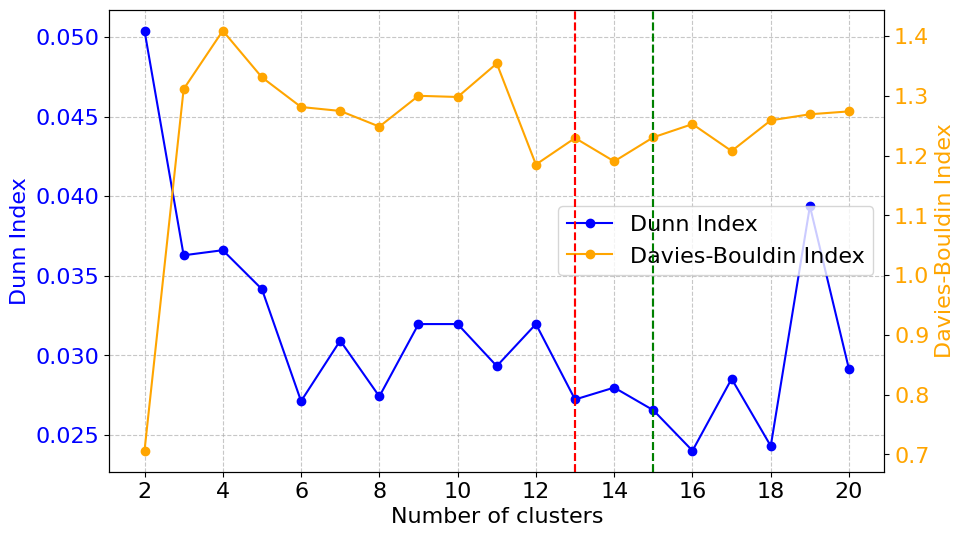

In [ ]:
## Plotting the clustering scores ##
plt.figure(figsize=(10, 6))
optimal_num = 12

# Dunn & DB Index
if Dunn_index == True and DB_index == True:

    # Création du graphique avec deux axes y
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Tracé de l'indice Dunn (axe y principal, couleur bleue)
    color_dunn = 'blue'
    ax1.set_xlabel('Number of clusters')
    ax1.set_ylabel('Dunn Index', color=color_dunn)
    line1 = ax1.plot(range(nmb_min_clusters, nmb_max_clusters + 1), Dunn_scores, label='Dunn Index', color=color_dunn, marker='o')
    ax1.tick_params(axis='y', labelcolor=color_dunn)
    ax1.grid(True, linestyle='--', alpha=0.7)

    # Ajout des lignes verticales pour l'indice Dunn
    ax1.axvline(optimal_num, color='red', linestyle='--', label=f'Optimal clusters ({optimal_num})')
    ax1.axvline(optimal_num + 2, color='green', linestyle='--', label=f'Optimal clusters + 2 ({optimal_num + 2})')

    # Création d'un deuxième axe y pour l'indice DB (couleur orange)
    ax2 = ax1.twinx()
    color_db = 'orange'
    ax2.set_ylabel('Davies-Bouldin Index', color=color_db)
    line2 = ax2.plot(range(nmb_min_clusters, nmb_max_clusters + 1), DB_scores, label='Davies-Bouldin Index', color=color_db, marker='o')
    ax2.tick_params(axis='y', labelcolor=color_db)

    # Ajout des lignes verticales pour l'indice DB (identiques à celles de l'indice Dunn)
    ax2.axvline(optimal_num, color='red', linestyle='--')
    ax2.axvline(optimal_num + 2, color='green', linestyle='--')

    # Légende combinée
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='center right')

    # Configuration des ticks et du titre
    ax1.set_xticks(range(nmb_min_clusters, nmb_max_clusters + 1, 2))
    #plt.title(f"Dunn and Davies-Bouldin Indices for {clustering_method}")

    plt.show()

elif Dunn_index == True and DB_index == False:

    plt.plot(range(nmb_min_clusters, nmb_max_clusters + 1), Dunn_scores, label='Dunn_index', color='blue')
    plt.axvline(optimal_num, color='r', linestyle='--')
    plt.axvline(optimal_num + 2, color='g', linestyle='--')
    plt.xlabel('Numbers of clusters')
    plt.ylabel('Index')
    plt.xticks(range(nmb_min_clusters, nmb_max_clusters + 1, 2))
    plt.grid()
    plt.legend()
    plt.title("Dunn index")
    plt.show()

elif Dunn_index == False and DB_index == True:

    plt.plot(range(nmb_min_clusters, nmb_max_clusters + 1), DB_scores, label='DB_index', color='orange')
    plt.axvline(optimal_num, color='r', linestyle='--')
    plt.axvline(optimal_num + 2, color='g', linestyle='--')
    plt.xlabel('Numbers of clusters')
    plt.ylabel('Index')
    plt.xticks(range(nmb_min_clusters, nmb_max_clusters + 1, 2))
    plt.grid()
    plt.legend()
    plt.title("Davies-Bouldin index")
    plt.show()